In [1]:
# ============================================================
# Libraries
# ============================================================

from pathlib import Path
import json
import shutil
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# ============================================================
# General variables
# ============================================================

stage1_label = "Stage 1"
stage2_label = "Stage 2"

stage1_frequency_MHz = 20
stage2_frequency_MHz = 85

# Output folder for this new comparison notebook
comparison_output_dir = Path("fwi_comparison_analysis_outputs")
comparison_fig_dir = comparison_output_dir / "figures"
comparison_table_dir = comparison_output_dir / "tables"
comparison_repro_dir = comparison_output_dir / "reproducibility"

comparison_output_dir.mkdir(exist_ok=True)
comparison_fig_dir.mkdir(exist_ok=True)
comparison_table_dir.mkdir(exist_ok=True)
comparison_repro_dir.mkdir(exist_ok=True)

# Useful plotting settings
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["font.size"] = 11

print("Comparison output folder:", comparison_output_dir.resolve())

Comparison output folder: /Users/mbarrionuevo/Downloads/jwave_keras_gui_workflow/jupytertest/fwi_comparison_analysis_outputs


In [3]:
# ============================================================
# Input experiment folders
# ============================================================
# Assumption:
#   This notebook is located in the same parent directory as the
#   FWI result folders.
# ============================================================

root_dir = Path(".").resolve()

experiments = {
    "6 ideal bands": {
        "folder": root_dir / "fwi_20MHz_to_85MHz_6bands_LIMIT_BENCHMARK_results",
        "experiment_type": "resolution_limit",
        "num_bands": 6,
        "geometry": "ideal_horizontal",
    },
    "8 ideal bands": {
        "folder": root_dir / "fwi_20MHz_to_85MHz_8bands_LIMIT_BENCHMARK_results",
        "experiment_type": "resolution_limit",
        "num_bands": 8,
        "geometry": "ideal_horizontal",
    },
    "10 ideal bands": {
        "folder": root_dir / "fwi_20MHz_to_85MHz_10bands_LIMIT_BENCHMARK_results",
        "experiment_type": "resolution_limit",
        "num_bands": 10,
        "geometry": "ideal_horizontal",
    },
    "3 irregular tectonic bands": {
        "folder": root_dir / "fwi_20MHz_to_85MHz_3bands_realistic_tectonic_results",
        "experiment_type": "realistic_tectonic",
        "num_bands": 3,
        "geometry": "irregular_tectonic",
    },
}

csv_files = {
    "map_long": "MAP_LONG_FORMAT_all_pixels_with_x_z_positions_band_labels_and_errors.csv",
    "global_metrics": "TABLE_global_reconstruction_metrics_READABLE.csv",
    "band_metrics": "TABLE_band_by_band_scientific_metrics_READABLE.csv",
    "improvement": "TABLE_stage1_vs_stage2_band_improvement_SCIENTIFIC_READABLE.csv",
    "boundary_deviation": "TABLE_tectonic_band_boundary_deviation_READABLE.csv",
    "background_metrics": "TABLE_background_non_band_silicon_metrics_READABLE.csv",
}

# Check folders
for name, info in experiments.items():
    folder = info["folder"]
    print(name, "->", folder)
    print("Exists:", folder.exists())

6 ideal bands -> /Users/mbarrionuevo/Downloads/jwave_keras_gui_workflow/jupytertest/fwi_20MHz_to_85MHz_6bands_LIMIT_BENCHMARK_results
Exists: True
8 ideal bands -> /Users/mbarrionuevo/Downloads/jwave_keras_gui_workflow/jupytertest/fwi_20MHz_to_85MHz_8bands_LIMIT_BENCHMARK_results
Exists: True
10 ideal bands -> /Users/mbarrionuevo/Downloads/jwave_keras_gui_workflow/jupytertest/fwi_20MHz_to_85MHz_10bands_LIMIT_BENCHMARK_results
Exists: True
3 irregular tectonic bands -> /Users/mbarrionuevo/Downloads/jwave_keras_gui_workflow/jupytertest/fwi_20MHz_to_85MHz_3bands_realistic_tectonic_results
Exists: True


In [4]:
# ============================================================
# Read CSV files from all experiments
# ============================================================

def read_csv_if_exists(path):
    if path.exists():
        return pd.read_csv(path)
    return None


loaded = {}

for experiment_name, info in experiments.items():

    folder = info["folder"]

    loaded[experiment_name] = {}

    print("\n========================================")
    print("Experiment:", experiment_name)
    print("Folder:", folder)
    print("========================================")

    for key, filename in csv_files.items():

        path = folder / filename
        df = read_csv_if_exists(path)

        if df is None:
            print("Missing:", filename)
            loaded[experiment_name][key] = None
            continue

        # Add metadata columns
        df["experiment_name"] = experiment_name
        df["experiment_type"] = info["experiment_type"]
        df["num_bands"] = info["num_bands"]
        df["geometry"] = info["geometry"]

        loaded[experiment_name][key] = df

        print("Loaded:", filename, "shape:", df.shape)


Experiment: 6 ideal bands
Folder: /Users/mbarrionuevo/Downloads/jwave_keras_gui_workflow/jupytertest/fwi_20MHz_to_85MHz_6bands_LIMIT_BENCHMARK_results
Loaded: MAP_LONG_FORMAT_all_pixels_with_x_z_positions_band_labels_and_errors.csv shape: (25920, 29)
Loaded: TABLE_global_reconstruction_metrics_READABLE.csv shape: (10, 14)
Loaded: TABLE_band_by_band_scientific_metrics_READABLE.csv shape: (12, 42)
Loaded: TABLE_stage1_vs_stage2_band_improvement_SCIENTIFIC_READABLE.csv shape: (6, 34)
Loaded: TABLE_tectonic_band_boundary_deviation_READABLE.csv shape: (12, 29)
Missing: TABLE_background_non_band_silicon_metrics_READABLE.csv

Experiment: 8 ideal bands
Folder: /Users/mbarrionuevo/Downloads/jwave_keras_gui_workflow/jupytertest/fwi_20MHz_to_85MHz_8bands_LIMIT_BENCHMARK_results
Loaded: MAP_LONG_FORMAT_all_pixels_with_x_z_positions_band_labels_and_errors.csv shape: (25920, 29)
Loaded: TABLE_global_reconstruction_metrics_READABLE.csv shape: (10, 14)
Loaded: TABLE_band_by_band_scientific_metrics_RE

In [5]:
# ============================================================
# Combine tables across experiments
# ============================================================

def concat_available(key):
    frames = []

    for experiment_name in loaded:
        df = loaded[experiment_name].get(key)

        if df is not None:
            frames.append(df)

    if len(frames) == 0:
        return pd.DataFrame()

    return pd.concat(frames, ignore_index=True)


global_all_df = concat_available("global_metrics")
band_all_df = concat_available("band_metrics")
improvement_all_df = concat_available("improvement")
boundary_all_df = concat_available("boundary_deviation")
background_all_df = concat_available("background_metrics")

print("Global metrics:", global_all_df.shape)
print("Band metrics:", band_all_df.shape)
print("Improvement:", improvement_all_df.shape)
print("Boundary deviation:", boundary_all_df.shape)
print("Background metrics:", background_all_df.shape)

display(global_all_df.head())
display(band_all_df.head())

Global metrics: (40, 14)
Band metrics: (54, 42)
Improvement: (27, 34)
Boundary deviation: (54, 29)
Background metrics: (3, 21)


,benchmark_num_bands,FWI stage,Stage description,Metric short name,Metric full name,Value,Unit,Formula used,Meaning,Good result,experiment_name,experiment_type,num_bands,geometry
0,6,Stage 1,20 MHz low-frequency FWI reconstruction,MAE,Mean Absolute Error,88.154907,m/s,mean(abs(reconstructed_speed - true_speed)),Average absolute velocity error inside the inv...,Lower is better.,6 ideal bands,resolution_limit,6,ideal_horizontal
1,6,Stage 1,20 MHz low-frequency FWI reconstruction,RMSE,Root Mean Squared Error,101.555908,m/s,sqrt(mean((reconstructed_speed - true_speed)^2)),"Typical velocity error, with large errors pena...",Lower is better.,6 ideal bands,resolution_limit,6,ideal_horizontal
2,6,Stage 1,20 MHz low-frequency FWI reconstruction,Bias,Mean Signed Error,0.461974,m/s,mean(reconstructed_speed - true_speed),Average signed error. Positive means too fast;...,Closer to zero is better.,6 ideal bands,resolution_limit,6,ideal_horizontal
3,6,Stage 1,20 MHz low-frequency FWI reconstruction,NRMSE,Normalized Root Mean Squared Error,15.053345,%,100 * RMSE / (max(true_speed) - min(true_speed)),RMSE expressed as percent of the true velocity...,Lower is better.,6 ideal bands,resolution_limit,6,ideal_horizontal
4,6,Stage 1,20 MHz low-frequency FWI reconstruction,Correlation,Pearson Spatial Correlation,0.759966,unitless,"corrcoef(reconstructed_speed_flat, true_speed_...",Spatial similarity between reconstructed and t...,Closer to 1 is better.,6 ideal bands,resolution_limit,6,ideal_horizontal


,tectonic_band_number,band_type,FWI stage,Stage description,true_top_depth_inside_silicon_micrometers,true_bottom_depth_inside_silicon_micrometers_exclusive,true_center_depth_inside_silicon_micrometers,true_thickness_micrometers,true_velocity_contrast_percent,true_band_speed_m_per_s,...,band_reconstruction_energy_expected_sign_m_per_s,background_artifact_energy_expected_sign_m_per_s,detection_efficiency_0_to_1,false_positive_ratio,wrong_sign_energy_inside_band_m_per_s,wrong_sign_ratio_inside_band,experiment_name,experiment_type,num_bands,geometry
0,1,fast band,Stage 1,20 MHz low-frequency FWI reconstruction,30.0,45.0,35.0,15.0,2.0,8601.66,...,107.68979,55.986477,0.657944,0.519887,0.0,0.0,6 ideal bands,resolution_limit,6,ideal_horizontal
1,1,fast band,Stage 2,85 MHz high-frequency FWI reconstruction initi...,30.0,45.0,35.0,15.0,2.0,8601.66,...,145.16684,50.003970,0.743794,0.344459,0.0,0.0,6 ideal bands,resolution_limit,6,ideal_horizontal
2,2,slow band,Stage 1,20 MHz low-frequency FWI reconstruction,70.0,85.0,75.0,15.0,-2.0,8264.34,...,140.54457,53.484676,0.724347,0.380553,0.0,0.0,6 ideal bands,resolution_limit,6,ideal_horizontal
3,2,slow band,Stage 2,85 MHz high-frequency FWI reconstruction initi...,70.0,85.0,75.0,15.0,-2.0,8264.34,...,113.99099,55.341328,0.673179,0.485489,0.0,0.0,6 ideal bands,resolution_limit,6,ideal_horizontal
4,3,fast band,Stage 1,20 MHz low-frequency FWI reconstruction,110.0,125.0,115.0,15.0,3.0,8685.99,...,169.10973,52.226074,0.764041,0.308830,0.0,0.0,6 ideal bands,resolution_limit,6,ideal_horizontal


In [20]:
# ============================================================
# Compute missing background metrics from MAP_LONG_FORMAT files
# ============================================================

def compute_background_metrics_from_map_long(df_map, experiment_name, info):
    """
    Reconstruct background/non-band metrics from MAP_LONG_FORMAT CSV.

    Background = inside inversion mask and silicon_background region.
    """

    df_bg = df_map[
        (df_map["inside_inversion_mask"] == "yes")
        & (df_map["region_label"] == "silicon_background")
    ].copy()

    if len(df_bg) == 0:
        print("No background pixels found for:", experiment_name)
        return pd.DataFrame()

    rows = []

    stage_info = [
        {
            "FWI stage": "Stage 1",
            "Stage description": "20 MHz low-frequency FWI reconstruction",
            "error_col": "stage1_error_reconstructed_minus_true_m_per_s",
            "update_col": "stage1_velocity_update_relative_to_initial_m_per_s",
        },
        {
            "FWI stage": "Stage 2",
            "Stage description": "85 MHz high-frequency FWI reconstruction initialized from Stage 1",
            "error_col": "stage2_error_reconstructed_minus_true_m_per_s",
            "update_col": "stage2_velocity_update_relative_to_initial_m_per_s",
        },
    ]

    thresholds = [25, 50, 100, 150, 200]

    for stage in stage_info:

        error = df_bg[stage["error_col"]].dropna().values
        update = df_bg[stage["update_col"]].dropna().values

        row = {
            "region": "silicon_background_outside_true_bands",
            "FWI stage": stage["FWI stage"],
            "Stage description": stage["Stage description"],
            "number_of_pixels": len(df_bg),

            "MAE_background_m_per_s": np.mean(np.abs(error)),
            "RMSE_background_m_per_s": np.sqrt(np.mean(error ** 2)),
            "Bias_background_m_per_s": np.mean(error),

            "mean_absolute_velocity_update_background_m_per_s": np.mean(np.abs(update)),
            "median_absolute_velocity_update_background_m_per_s": np.median(np.abs(update)),
            "max_absolute_velocity_update_background_m_per_s": np.max(np.abs(update)),

            "mean_positive_update_background_m_per_s": np.mean(np.maximum(update, 0.0)),
            "mean_negative_update_background_m_per_s": np.mean(np.maximum(-update, 0.0)),

            "experiment_name": experiment_name,
            "experiment_type": info["experiment_type"],
            "num_bands": info["num_bands"],
            "geometry": info["geometry"],
            "computed_from_map_long": "yes",
        }

        for threshold in thresholds:
            row[
                f"fraction_background_pixels_abs_update_ge_{threshold}_m_per_s"
            ] = np.mean(np.abs(update) >= threshold)

        rows.append(row)

    # Improvement row
    stage1_row = rows[0]
    stage2_row = rows[1]

    improvement_row = {
        "region": "silicon_background_outside_true_bands",
        "FWI stage": "Stage 2 minus Stage 1",
        "Stage description": "Positive improvement means background artifact/error decreased",
        "number_of_pixels": len(df_bg),

        "MAE_background_m_per_s": (
            stage1_row["MAE_background_m_per_s"]
            - stage2_row["MAE_background_m_per_s"]
        ),
        "RMSE_background_m_per_s": (
            stage1_row["RMSE_background_m_per_s"]
            - stage2_row["RMSE_background_m_per_s"]
        ),
        "Bias_background_m_per_s": (
            abs(stage1_row["Bias_background_m_per_s"])
            - abs(stage2_row["Bias_background_m_per_s"])
        ),
        "mean_absolute_velocity_update_background_m_per_s": (
            stage1_row["mean_absolute_velocity_update_background_m_per_s"]
            - stage2_row["mean_absolute_velocity_update_background_m_per_s"]
        ),
        "median_absolute_velocity_update_background_m_per_s": (
            stage1_row["median_absolute_velocity_update_background_m_per_s"]
            - stage2_row["median_absolute_velocity_update_background_m_per_s"]
        ),
        "max_absolute_velocity_update_background_m_per_s": (
            stage1_row["max_absolute_velocity_update_background_m_per_s"]
            - stage2_row["max_absolute_velocity_update_background_m_per_s"]
        ),
        "mean_positive_update_background_m_per_s": (
            stage1_row["mean_positive_update_background_m_per_s"]
            - stage2_row["mean_positive_update_background_m_per_s"]
        ),
        "mean_negative_update_background_m_per_s": (
            stage1_row["mean_negative_update_background_m_per_s"]
            - stage2_row["mean_negative_update_background_m_per_s"]
        ),

        "experiment_name": experiment_name,
        "experiment_type": info["experiment_type"],
        "num_bands": info["num_bands"],
        "geometry": info["geometry"],
        "computed_from_map_long": "yes",
    }

    for threshold in thresholds:
        col = f"fraction_background_pixels_abs_update_ge_{threshold}_m_per_s"
        improvement_row[col] = stage1_row[col] - stage2_row[col]

    rows.append(improvement_row)

    return pd.DataFrame(rows)


# ------------------------------------------------------------
# Fill missing background metrics
# ------------------------------------------------------------

background_frames = []

for experiment_name, info in experiments.items():

    existing_bg = loaded[experiment_name].get("background_metrics")

    if existing_bg is not None:
        existing_bg = existing_bg.copy()
        existing_bg["computed_from_map_long"] = "no"
        background_frames.append(existing_bg)
        print("Using existing background CSV for:", experiment_name)

    else:
        df_map = loaded[experiment_name].get("map_long")

        if df_map is None:
            print("Cannot compute background metrics, missing MAP_LONG for:", experiment_name)
            continue

        computed_bg = compute_background_metrics_from_map_long(
            df_map=df_map,
            experiment_name=experiment_name,
            info=info
        )

        background_frames.append(computed_bg)
        print("Computed background metrics from MAP_LONG for:", experiment_name)

background_all_df = pd.concat(background_frames, ignore_index=True)

display(background_all_df)

background_all_csv = comparison_table_dir / "COMBINED_background_metrics_existing_and_computed.csv"
background_all_df.to_csv(background_all_csv, index=False)

print("Saved:", background_all_csv)

Computed background metrics from MAP_LONG for: 6 ideal bands
Computed background metrics from MAP_LONG for: 8 ideal bands
Computed background metrics from MAP_LONG for: 10 ideal bands
Using existing background CSV for: 3 irregular tectonic bands


,region,FWI stage,Stage description,number_of_pixels,MAE_background_m_per_s,RMSE_background_m_per_s,Bias_background_m_per_s,mean_absolute_velocity_update_background_m_per_s,median_absolute_velocity_update_background_m_per_s,max_absolute_velocity_update_background_m_per_s,...,experiment_name,experiment_type,num_bands,geometry,computed_from_map_long,fraction_background_pixels_abs_update_ge_25_m_per_s,fraction_background_pixels_abs_update_ge_50_m_per_s,fraction_background_pixels_abs_update_ge_100_m_per_s,fraction_background_pixels_abs_update_ge_150_m_per_s,fraction_background_pixels_abs_update_ge_200_m_per_s
0,silicon_background_outside_true_bands,Stage 1,20 MHz low-frequency FWI reconstruction,2992,90.203152,105.538502,2.157088,90.203152,87.314940,243.243160,...,6 ideal bands,resolution_limit,6,ideal_horizontal,yes,0.860628,0.738636,0.425468,0.159091,0.018382
1,silicon_background_outside_true_bands,Stage 2,85 MHz high-frequency FWI reconstruction initi...,2992,79.538239,97.968669,-1.911367,79.538239,70.899415,279.210940,...,6 ideal bands,resolution_limit,6,ideal_horizontal,yes,0.791778,0.620655,0.365976,0.143382,0.020053
2,silicon_background_outside_true_bands,Stage 2 minus Stage 1,Positive improvement means background artifact...,2992,10.664913,7.569834,0.245722,10.664913,16.415525,-35.967780,...,6 ideal bands,resolution_limit,6,ideal_horizontal,yes,0.068850,0.117981,0.059492,0.015709,-0.001671
3,silicon_background_outside_true_bands,Stage 1,20 MHz low-frequency FWI reconstruction,3168,84.493469,99.796580,-0.993806,84.493469,83.634768,199.066400,...,8 ideal bands,resolution_limit,8,ideal_horizontal,yes,0.830177,0.694760,0.356692,0.152462,0.000000
4,silicon_background_outside_true_bands,Stage 2,85 MHz high-frequency FWI reconstruction initi...,3168,87.481393,104.899374,-0.372412,87.481393,73.556642,312.753420,...,8 ideal bands,resolution_limit,8,ideal_horizontal,yes,0.900253,0.661616,0.355429,0.173295,0.041351
5,silicon_background_outside_true_bands,Stage 2 minus Stage 1,Positive improvement means background artifact...,3168,-2.987923,-5.102794,0.621393,-2.987923,10.078125,-113.687020,...,8 ideal bands,resolution_limit,8,ideal_horizontal,yes,-0.070076,0.033144,0.001263,-0.020833,-0.041351
6,silicon_background_outside_true_bands,Stage 1,20 MHz low-frequency FWI reconstruction,2816,53.880952,77.830995,-24.359228,53.880952,40.492676,243.219240,...,10 ideal bands,resolution_limit,10,ideal_horizontal,yes,0.692827,0.334517,0.125355,0.096236,0.060369
7,silicon_background_outside_true_bands,Stage 2,85 MHz high-frequency FWI reconstruction initi...,2816,126.052308,145.388922,-0.097103,126.052308,128.866700,412.944340,...,10 ideal bands,resolution_limit,10,ideal_horizontal,yes,0.884588,0.782670,0.620739,0.430043,0.188920
8,silicon_background_outside_true_bands,Stage 2 minus Stage 1,Positive improvement means background artifact...,2816,-72.171356,-67.557926,24.262125,-72.171356,-88.374024,-169.725100,...,10 ideal bands,resolution_limit,10,ideal_horizontal,yes,-0.191761,-0.448153,-0.495384,-0.333807,-0.128551
9,silicon_background_outside_true_bands,Stage 1,20 MHz low-frequency FWI reconstruction,3234,122.777960,150.796570,48.987766,122.777960,104.244630,416.672850,...,3 irregular tectonic bands,realistic_tectonic,3,irregular_tectonic,no,0.897959,0.768707,0.519790,0.322820,0.190785


Saved: fwi_comparison_analysis_outputs/tables/COMBINED_background_metrics_existing_and_computed.csv


In [21]:
# ============================================================
# Create summary tables
# ============================================================

# ------------------------------------------------------------
# 1. Global Stage 1 vs Stage 2 summary
# ------------------------------------------------------------

global_summary = global_all_df.pivot_table(
    index=["experiment_name", "experiment_type", "num_bands", "geometry", "Metric short name"],
    columns="FWI stage",
    values="Value",
    aggfunc="first"
).reset_index()

if stage1_label in global_summary.columns and stage2_label in global_summary.columns:
    global_summary["Stage 2 minus Stage 1"] = (
        global_summary[stage2_label] - global_summary[stage1_label]
    )

    # For error metrics, positive improvement means Stage 1 - Stage 2
    global_summary["Improvement amount"] = np.where(
        global_summary["Metric short name"].isin(["MAE", "RMSE", "NRMSE"]),
        global_summary[stage1_label] - global_summary[stage2_label],
        global_summary[stage2_label] - global_summary[stage1_label],
    )

display(global_summary)

global_summary_csv = comparison_table_dir / "COMBINED_global_metrics_summary.csv"
global_summary.to_csv(global_summary_csv, index=False)

print("Saved:", global_summary_csv)


# ------------------------------------------------------------
# 2. Stage 2 resolution-limit summary
# ------------------------------------------------------------

resolution_stage2 = global_all_df[
    (global_all_df["experiment_type"] == "resolution_limit")
    & (global_all_df["FWI stage"] == stage2_label)
].copy()

resolution_stage2_summary = resolution_stage2.pivot_table(
    index=["experiment_name", "num_bands"],
    columns="Metric short name",
    values="Value",
    aggfunc="first"
).reset_index()

resolution_stage2_summary = resolution_stage2_summary.sort_values("num_bands")

display(resolution_stage2_summary)

resolution_stage2_csv = comparison_table_dir / "COMBINED_resolution_limit_stage2_global_metrics.csv"
resolution_stage2_summary.to_csv(resolution_stage2_csv, index=False)

print("Saved:", resolution_stage2_csv)


# ------------------------------------------------------------
# 3. Band recovery summary
# ------------------------------------------------------------

band_recovery_summary = band_all_df[
    band_all_df["FWI stage"].isin([stage1_label, stage2_label])
].copy()

keep_columns = [
    "experiment_name",
    "experiment_type",
    "num_bands",
    "geometry",
    "tectonic_band_number",
    "band_type",
    "FWI stage",
    "velocity_update_recovery_percent",
    "MAE_inside_band_m_per_s",
    "RMSE_inside_band_m_per_s",
    "detection_efficiency_0_to_1",
    "false_positive_ratio",
    "wrong_sign_ratio_inside_band",
]

band_recovery_summary = band_recovery_summary[
    [c for c in keep_columns if c in band_recovery_summary.columns]
]

display(band_recovery_summary.head())

band_recovery_csv = comparison_table_dir / "COMBINED_band_recovery_metrics.csv"
band_recovery_summary.to_csv(band_recovery_csv, index=False)

print("Saved:", band_recovery_csv)


# ------------------------------------------------------------
# 4. Boundary / thickness summary
# ------------------------------------------------------------

if not boundary_all_df.empty:

    boundary_summary = boundary_all_df[
        boundary_all_df["FWI stage"].isin([stage1_label, stage2_label])
    ].copy()

    boundary_keep_columns = [
        "experiment_name",
        "experiment_type",
        "num_bands",
        "geometry",
        "tectonic_band_number",
        "band_type",
        "FWI stage",
        "center_shift_micrometers",
        "thickness_change_micrometers",
        "detected_thickness_micrometers",
        "true_thickness_micrometers",
    ]

    boundary_summary = boundary_summary[
        [c for c in boundary_keep_columns if c in boundary_summary.columns]
    ]

    display(boundary_summary.head())

    boundary_summary_csv = comparison_table_dir / "COMBINED_boundary_thickness_metrics.csv"
    boundary_summary.to_csv(boundary_summary_csv, index=False)

    print("Saved:", boundary_summary_csv)

FWI stage,experiment_name,experiment_type,num_bands,geometry,Metric short name,Stage 1,Stage 2,Stage 2 minus Stage 1,Improvement amount
0,10 ideal bands,resolution_limit,10,ideal_horizontal,Bias,-18.196907,-0.589087,17.607820,17.607820
1,10 ideal bands,resolution_limit,10,ideal_horizontal,Correlation,0.364547,0.763063,0.398515,0.398515
2,10 ideal bands,resolution_limit,10,ideal_horizontal,MAE,151.924713,127.636719,-24.287994,24.287994
3,10 ideal bands,resolution_limit,10,ideal_horizontal,NRMSE,20.549004,14.199347,-6.349656,6.349656
4,10 ideal bands,resolution_limit,10,ideal_horizontal,RMSE,207.947784,143.691772,-64.256012,64.256012
5,3 irregular tectonic bands,realistic_tectonic,3,irregular_tectonic,Bias,-3.239550,0.553171,3.792720,3.792720
6,3 irregular tectonic bands,realistic_tectonic,3,irregular_tectonic,Correlation,0.723128,0.894706,0.171578,0.171578
7,3 irregular tectonic bands,realistic_tectonic,3,irregular_tectonic,MAE,147.470108,87.983147,-59.486961,59.486961
8,3 irregular tectonic bands,realistic_tectonic,3,irregular_tectonic,NRMSE,19.018717,12.421044,-6.597672,6.597672
9,3 irregular tectonic bands,realistic_tectonic,3,irregular_tectonic,RMSE,176.423294,115.221321,-61.201973,61.201973


Saved: fwi_comparison_analysis_outputs/tables/COMBINED_global_metrics_summary.csv


Metric short name,experiment_name,num_bands,Bias,Correlation,MAE,NRMSE,RMSE
1,6 ideal bands,6,-3.230853,0.800888,77.774818,13.816749,93.213333
2,8 ideal bands,8,-4.347771,0.779558,93.272820,12.803213,107.969528
0,10 ideal bands,10,-0.589087,0.763063,127.636719,14.199347,143.691772


Saved: fwi_comparison_analysis_outputs/tables/COMBINED_resolution_limit_stage2_global_metrics.csv


,experiment_name,experiment_type,num_bands,geometry,tectonic_band_number,band_type,FWI stage,velocity_update_recovery_percent,MAE_inside_band_m_per_s,RMSE_inside_band_m_per_s,detection_efficiency_0_to_1,false_positive_ratio,wrong_sign_ratio_inside_band
0,6 ideal bands,resolution_limit,6,ideal_horizontal,1,fast band,Stage 1,63.850220,60.970370,63.981133,0.657944,0.519887,0.0
1,6 ideal bands,resolution_limit,6,ideal_horizontal,1,fast band,Stage 2,86.070694,28.063736,32.837040,0.743794,0.344459,0.0
2,6 ideal bands,resolution_limit,6,ideal_horizontal,2,slow band,Stage 1,83.330110,29.851477,37.915810,0.724347,0.380553,0.0
3,6 ideal bands,resolution_limit,6,ideal_horizontal,2,slow band,Stage 2,67.586260,55.384033,60.709910,0.673179,0.485489,0.0
4,6 ideal bands,resolution_limit,6,ideal_horizontal,3,fast band,Stage 1,66.844430,83.880516,86.407040,0.764041,0.308830,0.0


Saved: fwi_comparison_analysis_outputs/tables/COMBINED_band_recovery_metrics.csv


,experiment_name,experiment_type,num_bands,geometry,tectonic_band_number,band_type,FWI stage,center_shift_micrometers,thickness_change_micrometers,detected_thickness_micrometers,true_thickness_micrometers
0,6 ideal bands,resolution_limit,6,ideal_horizontal,1,fast band,Stage 1,2.5,15.0,30.0,15.0
1,6 ideal bands,resolution_limit,6,ideal_horizontal,1,fast band,Stage 2,2.5,5.0,20.0,15.0
2,6 ideal bands,resolution_limit,6,ideal_horizontal,2,slow band,Stage 1,2.5,5.0,20.0,15.0
3,6 ideal bands,resolution_limit,6,ideal_horizontal,2,slow band,Stage 2,2.5,15.0,30.0,15.0
4,6 ideal bands,resolution_limit,6,ideal_horizontal,3,fast band,Stage 1,-2.5,15.0,30.0,15.0


Saved: fwi_comparison_analysis_outputs/tables/COMBINED_boundary_thickness_metrics.csv


In [22]:
# ============================================================
# Helper function for saving figures
# ============================================================

def save_figure(name):
    path = comparison_fig_dir / f"{name}.png"
    plt.savefig(path, bbox_inches="tight")
    print("Saved figure:", path)
    return path

Saved figure: fwi_comparison_analysis_outputs/figures/resolution_limit_stage2_MAE.png


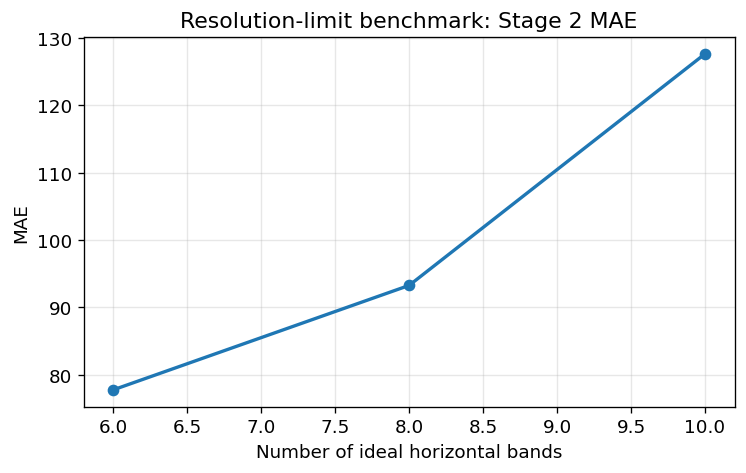

Saved figure: fwi_comparison_analysis_outputs/figures/resolution_limit_stage2_RMSE.png


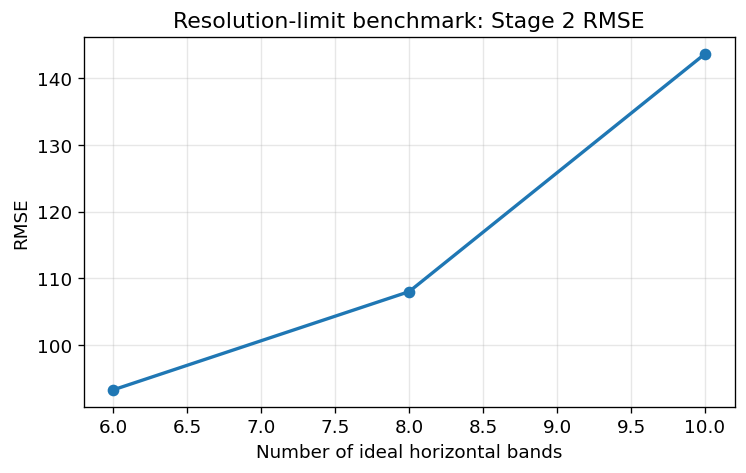

Saved figure: fwi_comparison_analysis_outputs/figures/resolution_limit_stage2_Correlation.png


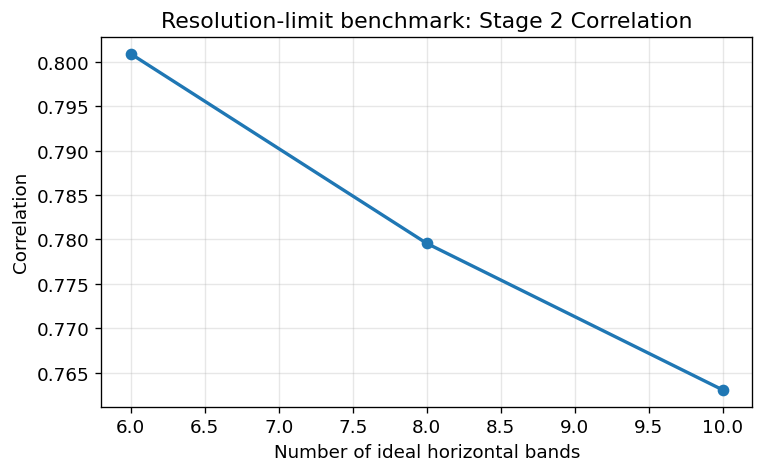

In [23]:
# ============================================================
# Graph 1: Resolution-limit global metrics, Stage 2
# ============================================================

metrics_to_plot = ["MAE", "RMSE", "Correlation"]

plot_df = resolution_stage2_summary.copy()

for metric in metrics_to_plot:

    if metric not in plot_df.columns:
        print("Missing metric:", metric)
        continue

    plt.figure(figsize=(7, 4))

    plt.plot(
        plot_df["num_bands"],
        plot_df[metric],
        marker="o",
        linewidth=2
    )

    plt.xlabel("Number of ideal horizontal bands")
    plt.ylabel(metric)
    plt.title(f"Resolution-limit benchmark: Stage 2 {metric}")
    plt.grid(True, alpha=0.3)

    save_figure(f"resolution_limit_stage2_{metric}")
    plt.show()

Saved figure: fwi_comparison_analysis_outputs/figures/band_recovery_6_ideal_bands.png


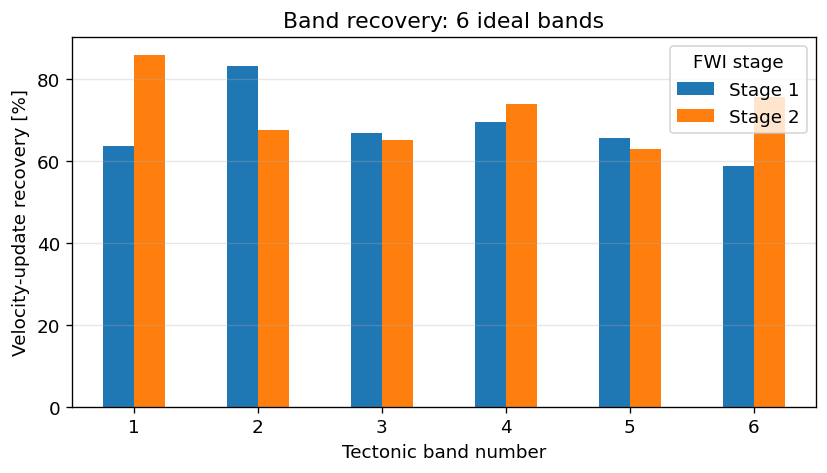

Saved figure: fwi_comparison_analysis_outputs/figures/band_recovery_8_ideal_bands.png


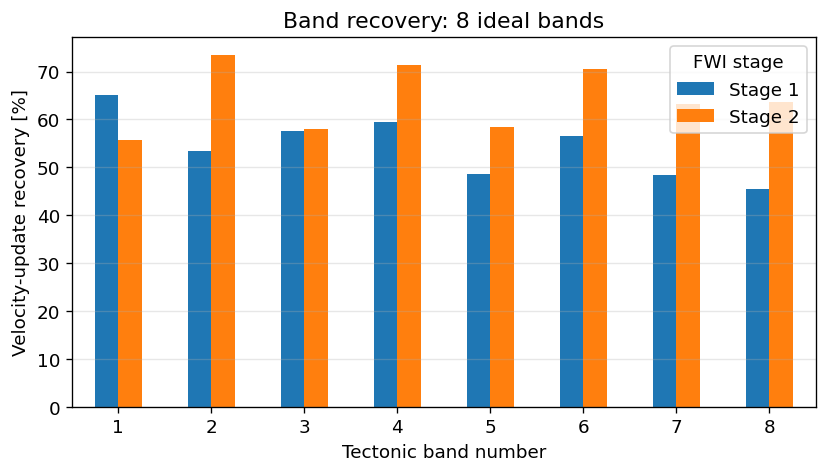

Saved figure: fwi_comparison_analysis_outputs/figures/band_recovery_10_ideal_bands.png


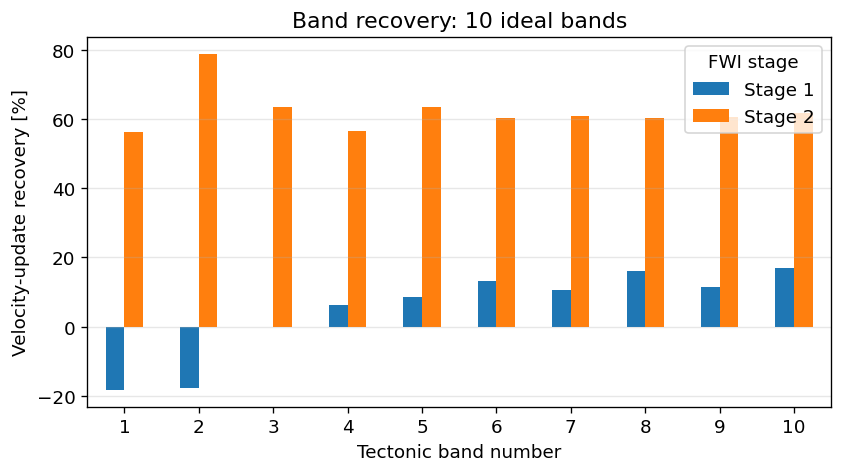

Saved figure: fwi_comparison_analysis_outputs/figures/band_recovery_3_irregular_tectonic_bands.png


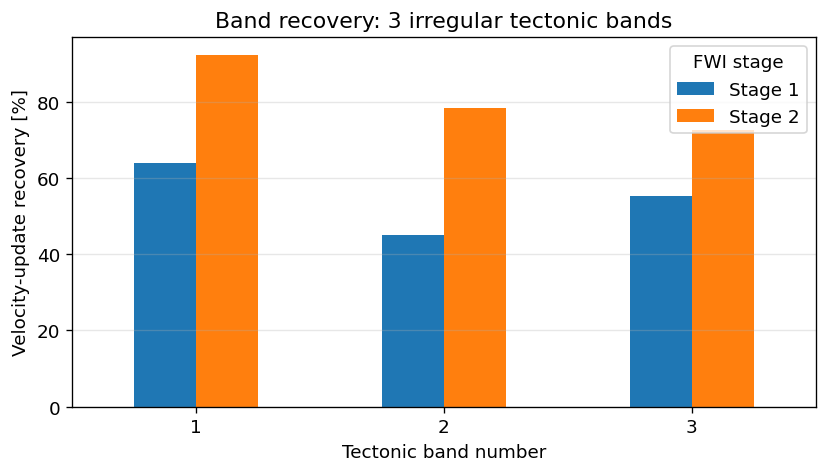

In [24]:
# ============================================================
# Graph 2: Band velocity-update recovery
# ============================================================

for experiment_name in band_recovery_summary["experiment_name"].unique():

    df = band_recovery_summary[
        band_recovery_summary["experiment_name"] == experiment_name
    ].copy()

    if "velocity_update_recovery_percent" not in df.columns:
        continue

    pivot = df.pivot_table(
        index="tectonic_band_number",
        columns="FWI stage",
        values="velocity_update_recovery_percent",
        aggfunc="first"
    )

    plt.figure(figsize=(8, 4))

    pivot.plot(
        kind="bar",
        ax=plt.gca(),
        rot=0
    )

    plt.xlabel("Tectonic band number")
    plt.ylabel("Velocity-update recovery [%]")
    plt.title(f"Band recovery: {experiment_name}")
    plt.grid(axis="y", alpha=0.3)
    plt.legend(title="FWI stage")

    safe_name = experiment_name.replace(" ", "_").replace("/", "_")
    save_figure(f"band_recovery_{safe_name}")

    plt.show()

Saved figure: fwi_comparison_analysis_outputs/figures/detection_efficiency_0_to_1_6_ideal_bands.png


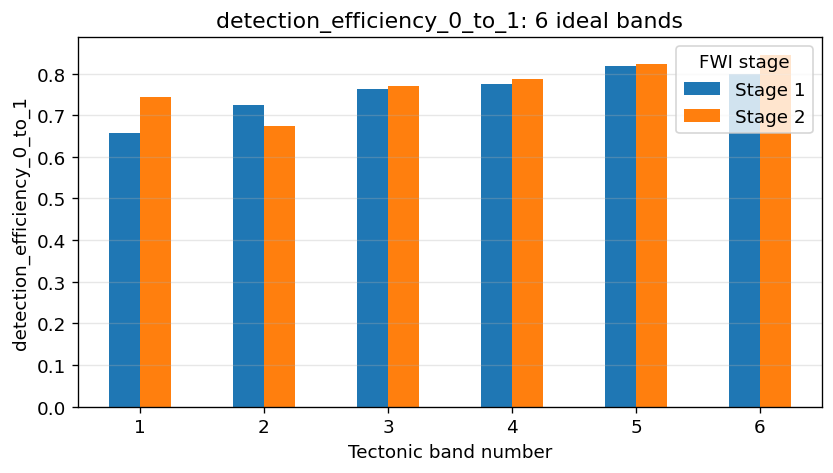

Saved figure: fwi_comparison_analysis_outputs/figures/detection_efficiency_0_to_1_8_ideal_bands.png


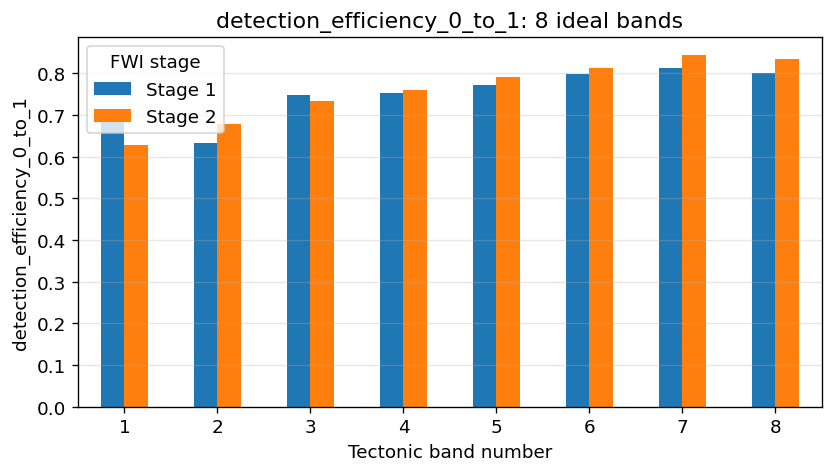

Saved figure: fwi_comparison_analysis_outputs/figures/detection_efficiency_0_to_1_10_ideal_bands.png


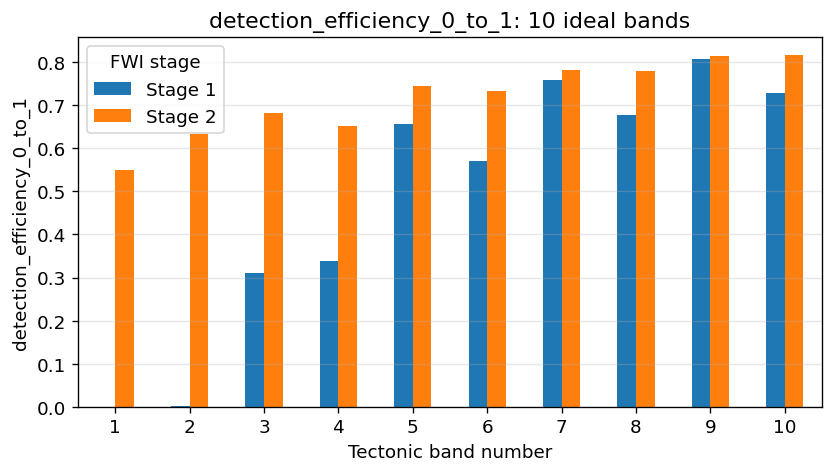

Saved figure: fwi_comparison_analysis_outputs/figures/detection_efficiency_0_to_1_3_irregular_tectonic_bands.png


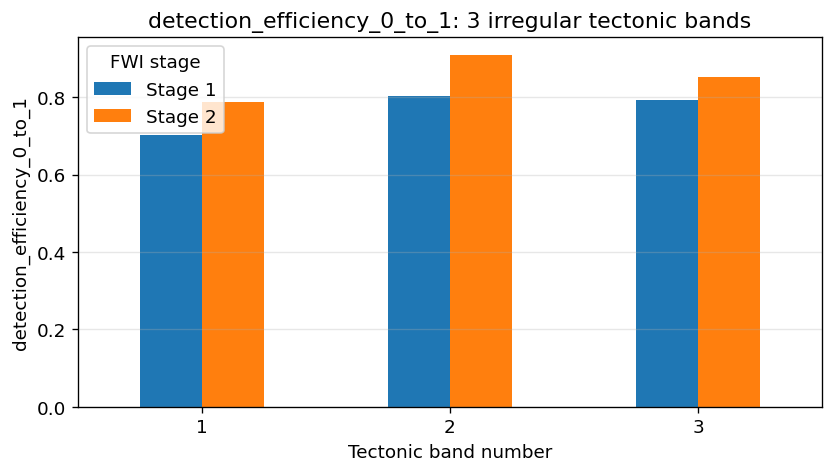

Saved figure: fwi_comparison_analysis_outputs/figures/false_positive_ratio_6_ideal_bands.png


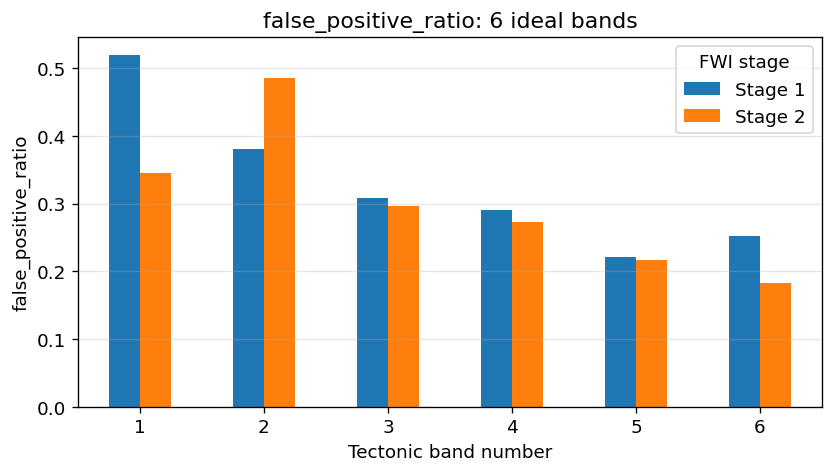

Saved figure: fwi_comparison_analysis_outputs/figures/false_positive_ratio_8_ideal_bands.png


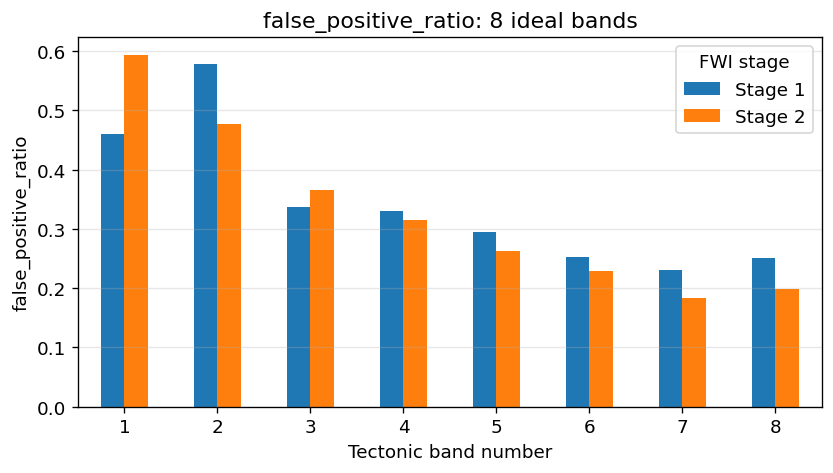

Saved figure: fwi_comparison_analysis_outputs/figures/false_positive_ratio_10_ideal_bands.png


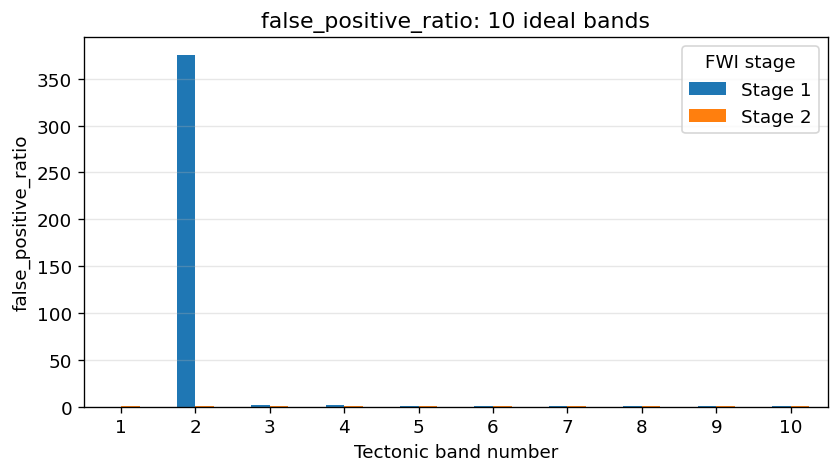

Saved figure: fwi_comparison_analysis_outputs/figures/false_positive_ratio_3_irregular_tectonic_bands.png


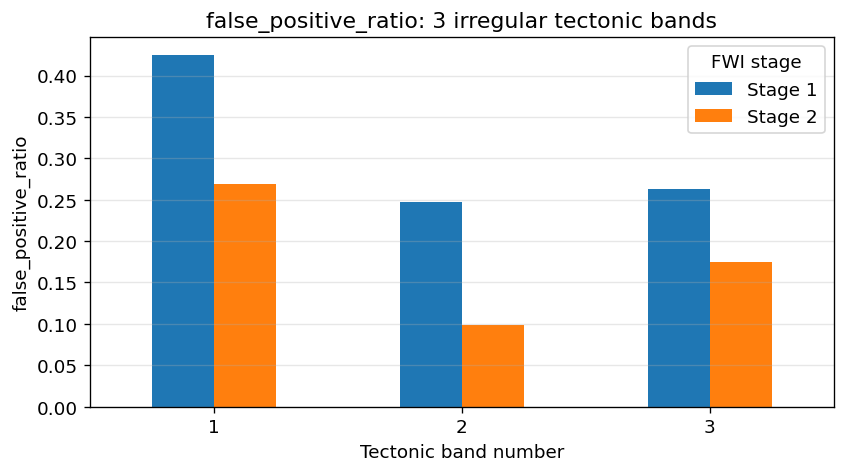

In [25]:
# ============================================================
# Graph 3: Detection efficiency and false positives
# ============================================================

for metric in ["detection_efficiency_0_to_1", "false_positive_ratio"]:

    if metric not in band_recovery_summary.columns:
        print("Missing metric:", metric)
        continue

    for experiment_name in band_recovery_summary["experiment_name"].unique():

        df = band_recovery_summary[
            band_recovery_summary["experiment_name"] == experiment_name
        ].copy()

        pivot = df.pivot_table(
            index="tectonic_band_number",
            columns="FWI stage",
            values=metric,
            aggfunc="first"
        )

        plt.figure(figsize=(8, 4))

        pivot.plot(
            kind="bar",
            ax=plt.gca(),
            rot=0
        )

        plt.xlabel("Tectonic band number")
        plt.ylabel(metric)
        plt.title(f"{metric}: {experiment_name}")
        plt.grid(axis="y", alpha=0.3)
        plt.legend(title="FWI stage")

        safe_name = experiment_name.replace(" ", "_").replace("/", "_")
        save_figure(f"{metric}_{safe_name}")

        plt.show()

Saved figure: fwi_comparison_analysis_outputs/figures/hist_resolution_limit_stage2_absolute_error.png


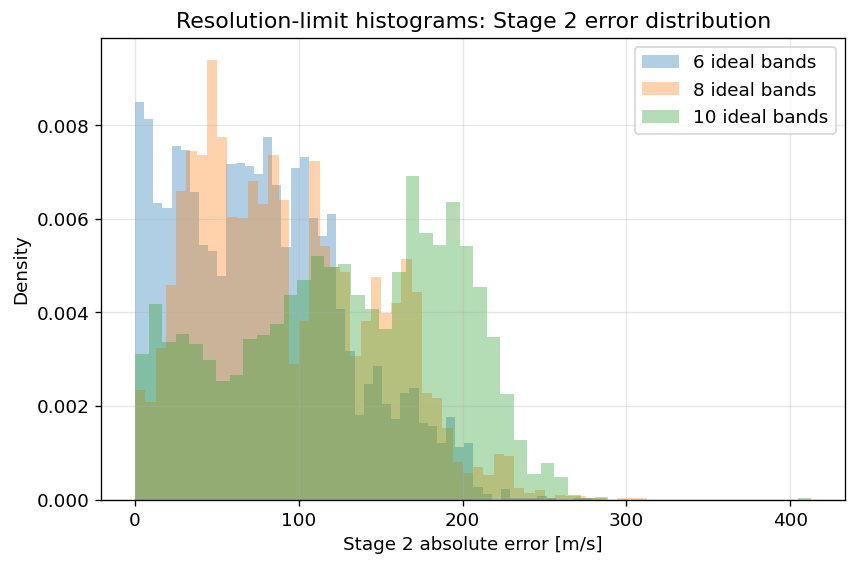

Saved figure: fwi_comparison_analysis_outputs/figures/hist_irregular_bands_stage1_vs_stage2_absolute_error.png


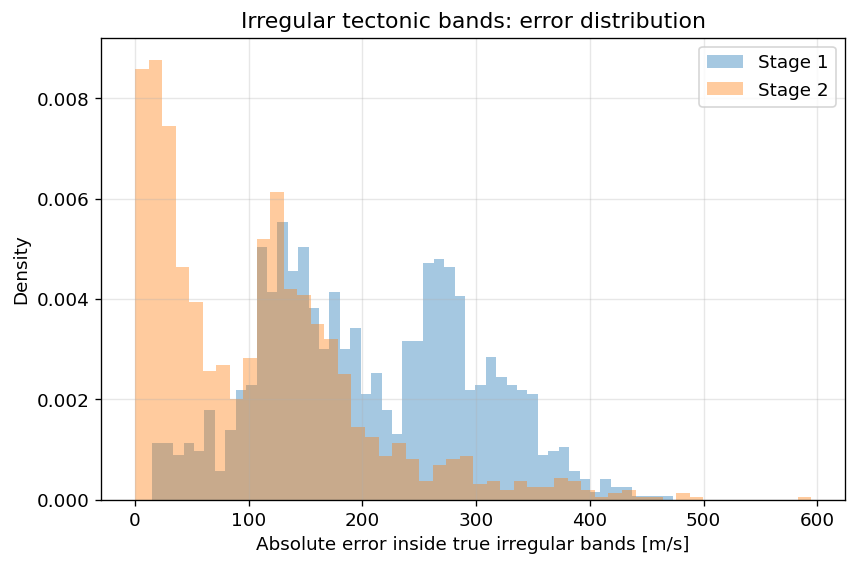

Saved figure: fwi_comparison_analysis_outputs/figures/hist_irregular_background_absolute_update.png


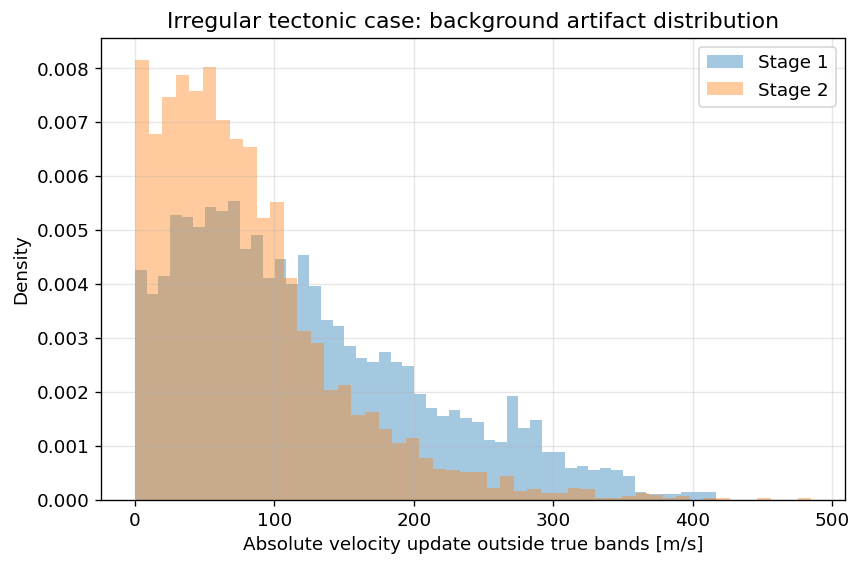

Saved figure: fwi_comparison_analysis_outputs/figures/hist_irregular_pixelwise_improvement_bands_vs_background.png


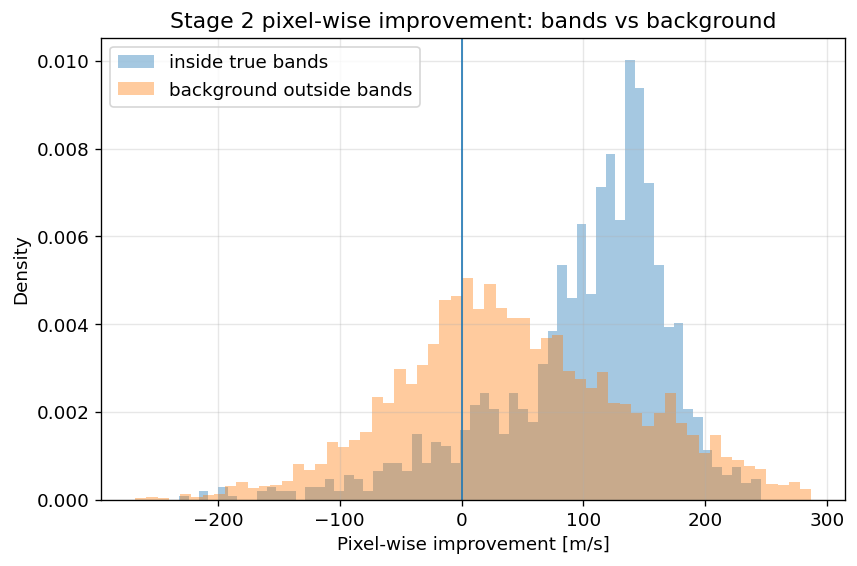

In [26]:
# ============================================================
# Graph 4: Histograms from pixel-level MAP_LONG_FORMAT CSVs
# ============================================================

def load_map_for_experiment(experiment_name):
    df = loaded[experiment_name].get("map_long")

    if df is None:
        print("No MAP_LONG_FORMAT file for:", experiment_name)
        return None

    return df.copy()


# ------------------------------------------------------------
# 4A. Stage 2 absolute error distribution for 6/8/10 limit cases
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

for experiment_name in ["6 ideal bands", "8 ideal bands", "10 ideal bands"]:

    df = load_map_for_experiment(experiment_name)

    if df is None:
        continue

    df_eval = df[
        df["inside_inversion_mask"] == "yes"
    ].copy()

    values = df_eval["stage2_absolute_error_m_per_s"].dropna().values

    plt.hist(
        values,
        bins=50,
        density=True,
        alpha=0.35,
        label=experiment_name
    )

plt.xlabel("Stage 2 absolute error [m/s]")
plt.ylabel("Density")
plt.title("Resolution-limit histograms: Stage 2 error distribution")
plt.legend()
plt.grid(True, alpha=0.3)

save_figure("hist_resolution_limit_stage2_absolute_error")
plt.show()


# ------------------------------------------------------------
# 4B. Irregular tectonic case: inside bands, Stage 1 vs Stage 2
# ------------------------------------------------------------

df_irregular = load_map_for_experiment("3 irregular tectonic bands")

if df_irregular is not None:

    df_bands = df_irregular[
        (df_irregular["inside_inversion_mask"] == "yes")
        & (df_irregular["tectonic_band_number"].notna())
    ].copy()

    plt.figure(figsize=(8, 5))

    plt.hist(
        df_bands["stage1_absolute_error_m_per_s"].dropna().values,
        bins=50,
        density=True,
        alpha=0.4,
        label="Stage 1"
    )

    plt.hist(
        df_bands["stage2_absolute_error_m_per_s"].dropna().values,
        bins=50,
        density=True,
        alpha=0.4,
        label="Stage 2"
    )

    plt.xlabel("Absolute error inside true irregular bands [m/s]")
    plt.ylabel("Density")
    plt.title("Irregular tectonic bands: error distribution")
    plt.legend()
    plt.grid(True, alpha=0.3)

    save_figure("hist_irregular_bands_stage1_vs_stage2_absolute_error")
    plt.show()


# ------------------------------------------------------------
# 4C. Irregular tectonic case: background artifact update
# ------------------------------------------------------------

if df_irregular is not None:

    df_background = df_irregular[
        (df_irregular["inside_inversion_mask"] == "yes")
        & (df_irregular["region_label"] == "silicon_background")
    ].copy()

    plt.figure(figsize=(8, 5))

    plt.hist(
        np.abs(df_background["stage1_velocity_update_relative_to_initial_m_per_s"].dropna().values),
        bins=50,
        density=True,
        alpha=0.4,
        label="Stage 1"
    )

    plt.hist(
        np.abs(df_background["stage2_velocity_update_relative_to_initial_m_per_s"].dropna().values),
        bins=50,
        density=True,
        alpha=0.4,
        label="Stage 2"
    )

    plt.xlabel("Absolute velocity update outside true bands [m/s]")
    plt.ylabel("Density")
    plt.title("Irregular tectonic case: background artifact distribution")
    plt.legend()
    plt.grid(True, alpha=0.3)

    save_figure("hist_irregular_background_absolute_update")
    plt.show()


# ------------------------------------------------------------
# 4D. Pixel-wise improvement: bands vs background
# ------------------------------------------------------------

if df_irregular is not None:

    df_eval = df_irregular[
        df_irregular["inside_inversion_mask"] == "yes"
    ].copy()

    df_eval["analysis_region"] = np.where(
        df_eval["tectonic_band_number"].notna(),
        "inside true bands",
        "background outside bands"
    )

    plt.figure(figsize=(8, 5))

    for region in ["inside true bands", "background outside bands"]:

        values = df_eval[
            df_eval["analysis_region"] == region
        ]["stage2_pixel_error_improvement_m_per_s"].dropna().values

        plt.hist(
            values,
            bins=60,
            density=True,
            alpha=0.4,
            label=region
        )

    plt.axvline(0, linewidth=1)

    plt.xlabel("Pixel-wise improvement [m/s]")
    plt.ylabel("Density")
    plt.title("Stage 2 pixel-wise improvement: bands vs background")
    plt.legend()
    plt.grid(True, alpha=0.3)

    save_figure("hist_irregular_pixelwise_improvement_bands_vs_background")
    plt.show()

Saved figure: fwi_comparison_analysis_outputs/figures/irregular_background_metrics_stage1_vs_stage2.png


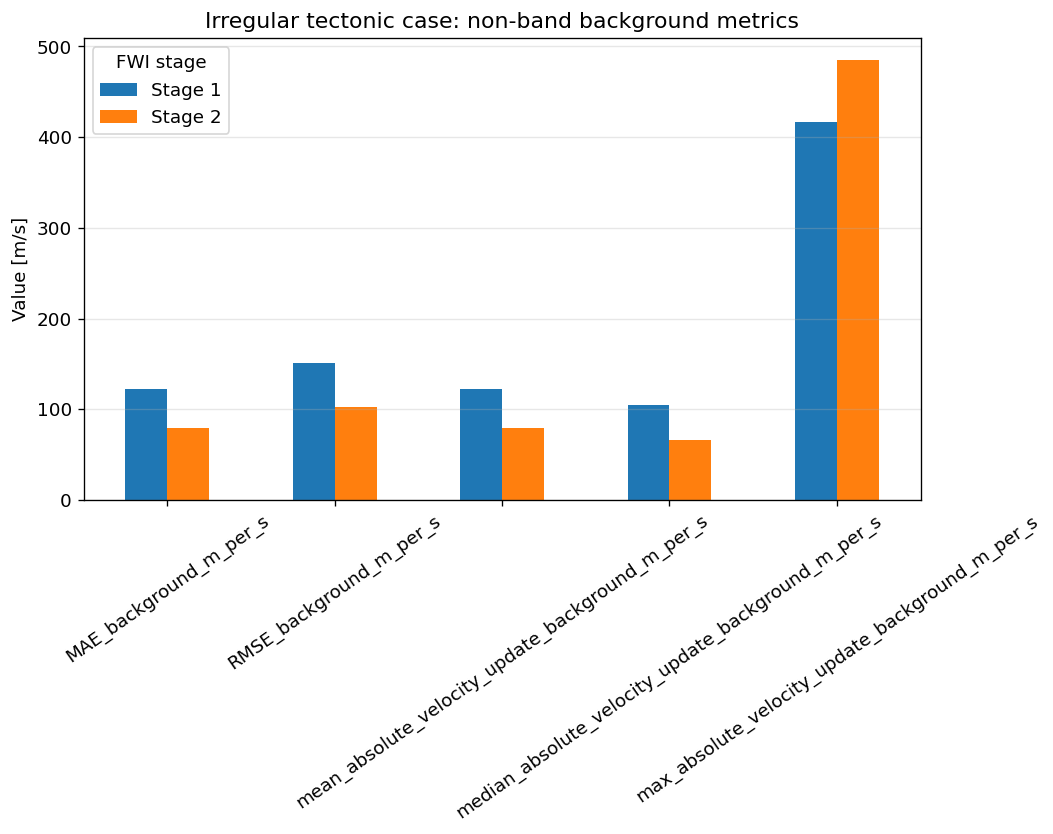

Saved figure: fwi_comparison_analysis_outputs/figures/irregular_background_threshold_fractions.png


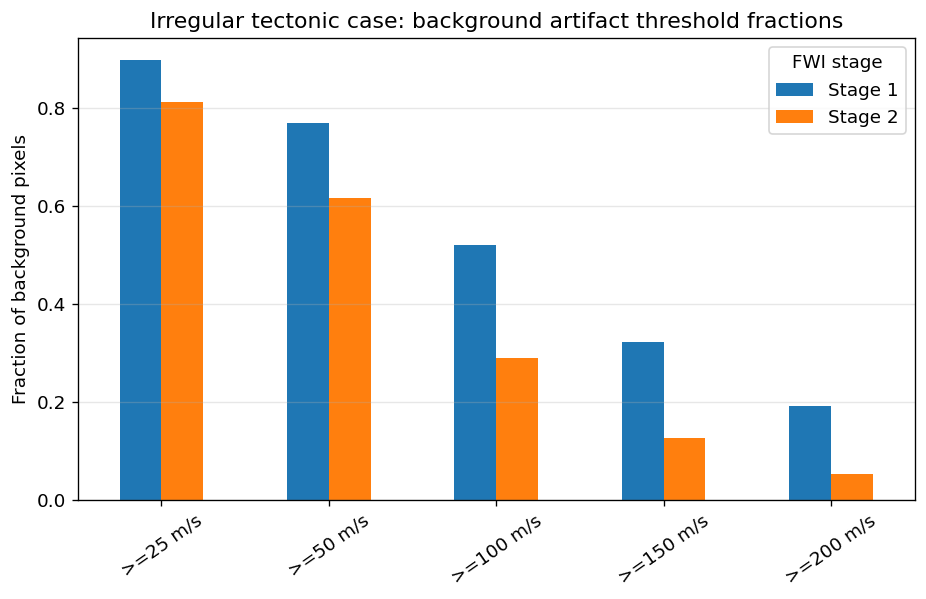

In [27]:
# ============================================================
# Graph 5: Background metrics for irregular tectonic case
# ============================================================

if not background_all_df.empty:

    bg_irregular = background_all_df[
        background_all_df["experiment_name"] == "3 irregular tectonic bands"
    ].copy()

    bg_stage = bg_irregular[
        bg_irregular["FWI stage"].isin([stage1_label, stage2_label])
    ].copy()

    metrics = [
        "MAE_background_m_per_s",
        "RMSE_background_m_per_s",
        "mean_absolute_velocity_update_background_m_per_s",
        "median_absolute_velocity_update_background_m_per_s",
        "max_absolute_velocity_update_background_m_per_s",
    ]

    available_metrics = [m for m in metrics if m in bg_stage.columns]

    plot_df = bg_stage.set_index("FWI stage")[available_metrics].T

    plt.figure(figsize=(9, 5))

    plot_df.plot(
        kind="bar",
        ax=plt.gca(),
        rot=35
    )

    plt.ylabel("Value [m/s]")
    plt.title("Irregular tectonic case: non-band background metrics")
    plt.grid(axis="y", alpha=0.3)
    plt.legend(title="FWI stage")

    save_figure("irregular_background_metrics_stage1_vs_stage2")
    plt.show()


    # Threshold fractions
    threshold_cols = [
        c for c in bg_stage.columns
        if c.startswith("fraction_background_pixels_abs_update_ge_")
    ]

    if len(threshold_cols) > 0:

        threshold_plot_df = bg_stage.set_index("FWI stage")[threshold_cols].T

        # Cleaner labels
        threshold_plot_df.index = [
            col.replace("fraction_background_pixels_abs_update_ge_", ">=")
               .replace("_m_per_s", " m/s")
            for col in threshold_plot_df.index
        ]

        plt.figure(figsize=(9, 5))

        threshold_plot_df.plot(
            kind="bar",
            ax=plt.gca(),
            rot=35
        )

        plt.ylabel("Fraction of background pixels")
        plt.title("Irregular tectonic case: background artifact threshold fractions")
        plt.grid(axis="y", alpha=0.3)
        plt.legend(title="FWI stage")

        save_figure("irregular_background_threshold_fractions")
        plt.show()

In [28]:
# ============================================================
# Save final combined files and reproducibility package
# ============================================================

# ------------------------------------------------------------
# Save combined raw tables
# ------------------------------------------------------------

combined_tables = {
    "COMBINED_raw_global_metrics.csv": global_all_df,
    "COMBINED_raw_band_metrics.csv": band_all_df,
    "COMBINED_raw_improvement.csv": improvement_all_df,
    "COMBINED_raw_boundary_deviation.csv": boundary_all_df,
    "COMBINED_raw_background_metrics.csv": background_all_df,
}

for filename, df in combined_tables.items():
    if df is not None and not df.empty:
        path = comparison_table_dir / filename
        df.to_csv(path, index=False)
        print("Saved:", path)


# ------------------------------------------------------------
# Save experiment configuration
# ------------------------------------------------------------

experiment_config = {}

for name, info in experiments.items():
    experiment_config[name] = {
        "folder": str(info["folder"]),
        "experiment_type": info["experiment_type"],
        "num_bands": info["num_bands"],
        "geometry": info["geometry"],
    }

config_path = comparison_repro_dir / "comparison_experiment_config.json"

with open(config_path, "w") as f:
    json.dump(experiment_config, f, indent=4)

print("Saved:", config_path)


# ------------------------------------------------------------
# Save CSV manifest
# ------------------------------------------------------------

manifest_rows = []

for experiment_name, info in experiments.items():

    folder = info["folder"]

    for key, filename in csv_files.items():

        path = folder / filename

        manifest_rows.append({
            "experiment_name": experiment_name,
            "experiment_type": info["experiment_type"],
            "num_bands": info["num_bands"],
            "geometry": info["geometry"],
            "csv_key": key,
            "filename": filename,
            "path": str(path),
            "exists": path.exists(),
        })

manifest_df = pd.DataFrame(manifest_rows)

manifest_path = comparison_repro_dir / "comparison_input_manifest.csv"
manifest_df.to_csv(manifest_path, index=False)

display(manifest_df)

print("Saved:", manifest_path)


# ------------------------------------------------------------
# Save simple README
# ------------------------------------------------------------

readme_text = """
FWI comparison analysis outputs
===============================

This folder contains the comparison analysis across:

1. 6 ideal horizontal bands
2. 8 ideal horizontal bands
3. 10 ideal horizontal bands
4. 3 irregular realistic tectonic bands

Purpose
-------
- The 6/8/10 ideal-band experiments are used to evaluate the resolution limit.
- The 3-band irregular tectonic experiment is used to evaluate realistic geometry recovery.
- Pixel-level histograms are produced from MAP_LONG_FORMAT CSV files.
- Summary tables are produced from global, band-by-band, improvement, boundary, and background CSVs.

Main outputs
------------
- figures/: saved comparison figures
- tables/: combined CSV tables
- reproducibility/: input manifest and experiment configuration
"""

readme_path = comparison_output_dir / "README.txt"

with open(readme_path, "w") as f:
    f.write(readme_text)

print("Saved:", readme_path)


# ------------------------------------------------------------
# Create zip archive of comparison outputs
# ------------------------------------------------------------

zip_path = Path("fwi_comparison_analysis_outputs.zip")

if zip_path.exists():
    zip_path.unlink()

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zipf:

    for file_path in comparison_output_dir.rglob("*"):

        if file_path.is_file():
            zipf.write(
                file_path,
                arcname=file_path.relative_to(comparison_output_dir.parent)
            )

print("Saved reproducibility archive:", zip_path.resolve())

Saved: fwi_comparison_analysis_outputs/tables/COMBINED_raw_global_metrics.csv
Saved: fwi_comparison_analysis_outputs/tables/COMBINED_raw_band_metrics.csv
Saved: fwi_comparison_analysis_outputs/tables/COMBINED_raw_improvement.csv
Saved: fwi_comparison_analysis_outputs/tables/COMBINED_raw_boundary_deviation.csv
Saved: fwi_comparison_analysis_outputs/tables/COMBINED_raw_background_metrics.csv
Saved: fwi_comparison_analysis_outputs/reproducibility/comparison_experiment_config.json


,experiment_name,experiment_type,num_bands,geometry,csv_key,filename,path,exists
0,6 ideal bands,resolution_limit,6,ideal_horizontal,map_long,MAP_LONG_FORMAT_all_pixels_with_x_z_positions_...,/Users/mbarrionuevo/Downloads/jwave_keras_gui_...,True
1,6 ideal bands,resolution_limit,6,ideal_horizontal,global_metrics,TABLE_global_reconstruction_metrics_READABLE.csv,/Users/mbarrionuevo/Downloads/jwave_keras_gui_...,True
2,6 ideal bands,resolution_limit,6,ideal_horizontal,band_metrics,TABLE_band_by_band_scientific_metrics_READABLE...,/Users/mbarrionuevo/Downloads/jwave_keras_gui_...,True
3,6 ideal bands,resolution_limit,6,ideal_horizontal,improvement,TABLE_stage1_vs_stage2_band_improvement_SCIENT...,/Users/mbarrionuevo/Downloads/jwave_keras_gui_...,True
4,6 ideal bands,resolution_limit,6,ideal_horizontal,boundary_deviation,TABLE_tectonic_band_boundary_deviation_READABL...,/Users/mbarrionuevo/Downloads/jwave_keras_gui_...,True
5,6 ideal bands,resolution_limit,6,ideal_horizontal,background_metrics,TABLE_background_non_band_silicon_metrics_READ...,/Users/mbarrionuevo/Downloads/jwave_keras_gui_...,False
6,8 ideal bands,resolution_limit,8,ideal_horizontal,map_long,MAP_LONG_FORMAT_all_pixels_with_x_z_positions_...,/Users/mbarrionuevo/Downloads/jwave_keras_gui_...,True
7,8 ideal bands,resolution_limit,8,ideal_horizontal,global_metrics,TABLE_global_reconstruction_metrics_READABLE.csv,/Users/mbarrionuevo/Downloads/jwave_keras_gui_...,True
8,8 ideal bands,resolution_limit,8,ideal_horizontal,band_metrics,TABLE_band_by_band_scientific_metrics_READABLE...,/Users/mbarrionuevo/Downloads/jwave_keras_gui_...,True
9,8 ideal bands,resolution_limit,8,ideal_horizontal,improvement,TABLE_stage1_vs_stage2_band_improvement_SCIENT...,/Users/mbarrionuevo/Downloads/jwave_keras_gui_...,True


Saved: fwi_comparison_analysis_outputs/reproducibility/comparison_input_manifest.csv
Saved: fwi_comparison_analysis_outputs/README.txt
Saved reproducibility archive: /Users/mbarrionuevo/Downloads/jwave_keras_gui_workflow/jupytertest/fwi_comparison_analysis_outputs.zip


In [29]:
# ============================================================
# Histogram-style plots for FWI pixel distributions
# Similar to board sketch: bars + smooth density curve
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ------------------------------------------------------------
# Input: choose the realistic tectonic MAP_LONG_FORMAT CSV
# ------------------------------------------------------------

map_csv = (
    Path("fwi_20MHz_to_85MHz_3bands_realistic_tectonic_results")
    / "MAP_LONG_FORMAT_all_pixels_with_x_z_positions_band_labels_and_errors.csv"
)

df = pd.read_csv(map_csv)

# Output folder
hist_fig_dir = Path("fwi_comparison_analysis_outputs") / "figures" / "histograms"
hist_fig_dir.mkdir(parents=True, exist_ok=True)

print("Loaded:", map_csv)
print("Shape:", df.shape)
print(df.columns.tolist())

Loaded: fwi_20MHz_to_85MHz_3bands_realistic_tectonic_results/MAP_LONG_FORMAT_all_pixels_with_x_z_positions_band_labels_and_errors.csv
Shape: (25920, 25)
['row_index_z_depth_direction', 'column_index_x_horizontal_direction', 'z_depth_global_micrometers', 'x_position_global_micrometers', 'z_depth_inside_silicon_micrometers', 'x_position_inside_silicon_micrometers', 'inside_silicon_sample', 'inside_inversion_mask', 'region_label', 'tectonic_band_number', 'tectonic_band_type', 'true_sound_speed_m_per_s', 'true_velocity_contrast_percent_relative_to_silicon', 'true_band_contrast_percent', 'initial_sound_speed_m_per_s', 'stage1_sound_speed_m_per_s', 'stage2_sound_speed_m_per_s', 'stage1_velocity_update_relative_to_initial_m_per_s', 'stage2_velocity_update_relative_to_initial_m_per_s', 'stage2_extra_update_relative_to_stage1_m_per_s', 'stage1_error_reconstructed_minus_true_m_per_s', 'stage2_error_reconstructed_minus_true_m_per_s', 'stage1_absolute_error_m_per_s', 'stage2_absolute_error_m_per_s

In [30]:
# ============================================================
# Helper function: histogram with smooth curve
# ============================================================

def smooth_histogram_curve(values, bins=60, smoothing_window=5):
    """
    Convert histogram counts into a smoothed curve.
    This avoids needing scipy and gives a clean curve over the bars.
    """

    values = np.asarray(values)
    values = values[np.isfinite(values)]

    counts, edges = np.histogram(values, bins=bins, density=True)

    centers = 0.5 * (edges[:-1] + edges[1:])

    if smoothing_window > 1:
        kernel = np.ones(smoothing_window) / smoothing_window
        counts_smooth = np.convolve(counts, kernel, mode="same")
    else:
        counts_smooth = counts

    return centers, counts_smooth


def plot_histogram_with_curve(
    values,
    title,
    xlabel,
    output_name,
    bins=60,
    smoothing_window=5,
    vertical_zero=True
):
    """
    Plot one histogram with a smooth curve over it.
    """

    values = np.asarray(values)
    values = values[np.isfinite(values)]

    plt.figure(figsize=(8, 5))

    plt.hist(
        values,
        bins=bins,
        density=True,
        alpha=0.45,
        edgecolor="black",
        linewidth=0.4,
        label="Pixel histogram"
    )

    centers, curve = smooth_histogram_curve(
        values,
        bins=bins,
        smoothing_window=smoothing_window
    )

    plt.plot(
        centers,
        curve,
        linewidth=2.5,
        label="Smoothed distribution"
    )

    if vertical_zero:
        plt.axvline(
            0,
            linewidth=1.5,
            linestyle="--",
            label="Zero"
        )

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Density")
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.tight_layout()

    save_path = hist_fig_dir / f"{output_name}.png"
    plt.savefig(save_path, dpi=300, bbox_inches="tight")

    print("Saved:", save_path)

    plt.show()

Saved: fwi_comparison_analysis_outputs/figures/histograms/hist_stage1_signed_error_inside_irregular_bands.png


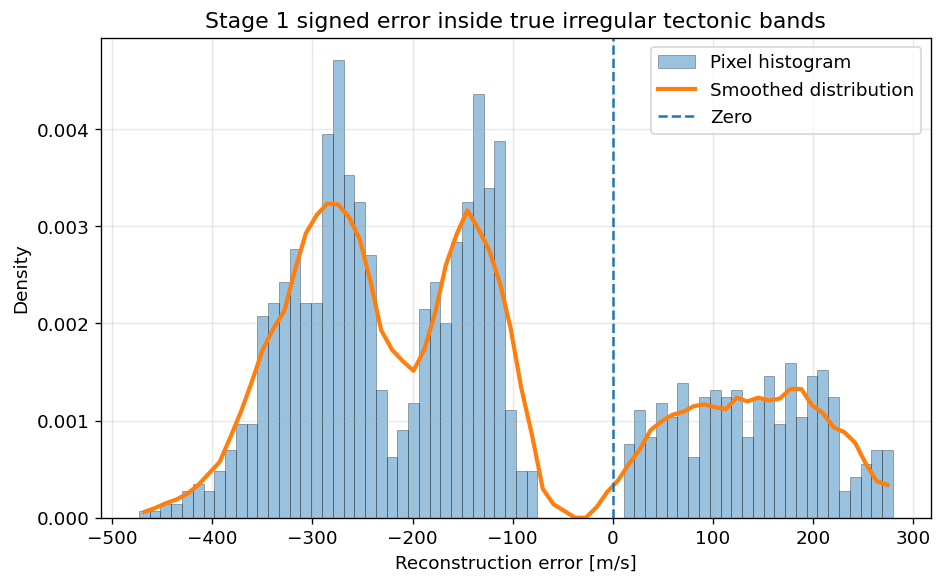

Saved: fwi_comparison_analysis_outputs/figures/histograms/hist_stage2_signed_error_inside_irregular_bands.png


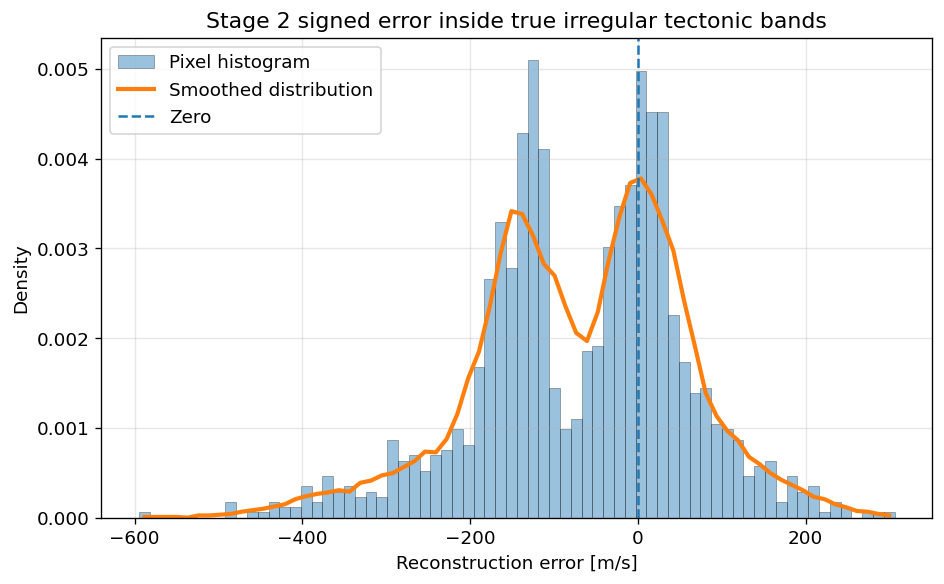

In [31]:
# ============================================================
# Histogram 1: signed error inside true irregular bands
# ============================================================

df_bands = df[
    (df["inside_inversion_mask"] == "yes")
    & (df["tectonic_band_number"].notna())
].copy()

plot_histogram_with_curve(
    values=df_bands["stage1_error_reconstructed_minus_true_m_per_s"],
    title="Stage 1 signed error inside true irregular tectonic bands",
    xlabel="Reconstruction error [m/s]",
    output_name="hist_stage1_signed_error_inside_irregular_bands",
    bins=70,
    smoothing_window=7
)

plot_histogram_with_curve(
    values=df_bands["stage2_error_reconstructed_minus_true_m_per_s"],
    title="Stage 2 signed error inside true irregular tectonic bands",
    xlabel="Reconstruction error [m/s]",
    output_name="hist_stage2_signed_error_inside_irregular_bands",
    bins=70,
    smoothing_window=7
)

Saved: fwi_comparison_analysis_outputs/figures/histograms/hist_overlay_stage1_stage2_signed_error_inside_bands.png


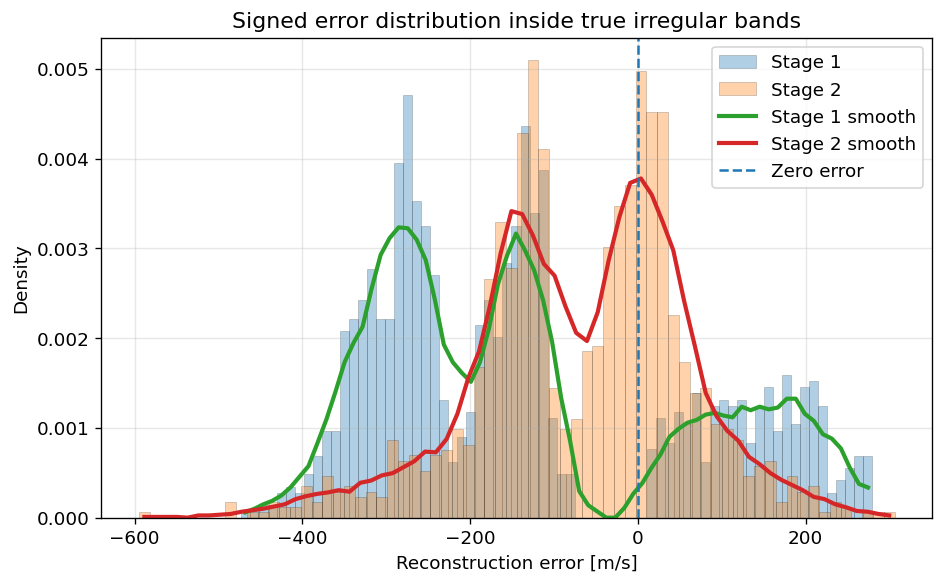

In [32]:
# ============================================================
# Histogram 2: Overlay Stage 1 vs Stage 2 inside bands
# ============================================================

stage1_values = df_bands["stage1_error_reconstructed_minus_true_m_per_s"].dropna().values
stage2_values = df_bands["stage2_error_reconstructed_minus_true_m_per_s"].dropna().values

plt.figure(figsize=(8, 5))

bins = 70

plt.hist(
    stage1_values,
    bins=bins,
    density=True,
    alpha=0.35,
    edgecolor="black",
    linewidth=0.3,
    label="Stage 1"
)

plt.hist(
    stage2_values,
    bins=bins,
    density=True,
    alpha=0.35,
    edgecolor="black",
    linewidth=0.3,
    label="Stage 2"
)

c1_x, c1_y = smooth_histogram_curve(stage1_values, bins=bins, smoothing_window=7)
c2_x, c2_y = smooth_histogram_curve(stage2_values, bins=bins, smoothing_window=7)

plt.plot(c1_x, c1_y, linewidth=2.5, label="Stage 1 smooth")
plt.plot(c2_x, c2_y, linewidth=2.5, label="Stage 2 smooth")

plt.axvline(0, linewidth=1.5, linestyle="--", label="Zero error")

plt.title("Signed error distribution inside true irregular bands")
plt.xlabel("Reconstruction error [m/s]")
plt.ylabel("Density")
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()

save_path = hist_fig_dir / "hist_overlay_stage1_stage2_signed_error_inside_bands.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
print("Saved:", save_path)

plt.show()

Saved: fwi_comparison_analysis_outputs/figures/histograms/hist_background_artifact_distribution_outside_bands.png


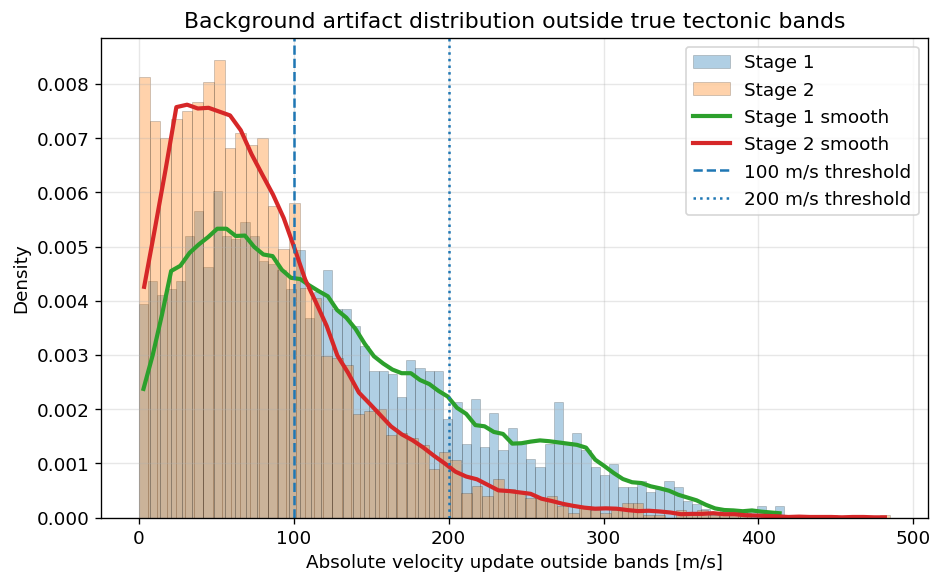

In [33]:
# ============================================================
# Histogram 3: Background artifact distribution outside true bands
# ============================================================

df_background = df[
    (df["inside_inversion_mask"] == "yes")
    & (df["region_label"] == "silicon_background")
].copy()

stage1_bg_update = np.abs(
    df_background["stage1_velocity_update_relative_to_initial_m_per_s"]
).dropna().values

stage2_bg_update = np.abs(
    df_background["stage2_velocity_update_relative_to_initial_m_per_s"]
).dropna().values

plt.figure(figsize=(8, 5))

bins = 70

plt.hist(
    stage1_bg_update,
    bins=bins,
    density=True,
    alpha=0.35,
    edgecolor="black",
    linewidth=0.3,
    label="Stage 1"
)

plt.hist(
    stage2_bg_update,
    bins=bins,
    density=True,
    alpha=0.35,
    edgecolor="black",
    linewidth=0.3,
    label="Stage 2"
)

c1_x, c1_y = smooth_histogram_curve(stage1_bg_update, bins=bins, smoothing_window=7)
c2_x, c2_y = smooth_histogram_curve(stage2_bg_update, bins=bins, smoothing_window=7)

plt.plot(c1_x, c1_y, linewidth=2.5, label="Stage 1 smooth")
plt.plot(c2_x, c2_y, linewidth=2.5, label="Stage 2 smooth")

plt.axvline(100, linewidth=1.5, linestyle="--", label="100 m/s threshold")
plt.axvline(200, linewidth=1.5, linestyle=":", label="200 m/s threshold")

plt.title("Background artifact distribution outside true tectonic bands")
plt.xlabel("Absolute velocity update outside bands [m/s]")
plt.ylabel("Density")
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()

save_path = hist_fig_dir / "hist_background_artifact_distribution_outside_bands.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
print("Saved:", save_path)

plt.show()

Saved: fwi_comparison_analysis_outputs/figures/histograms/hist_pixelwise_improvement_bands_vs_background.png


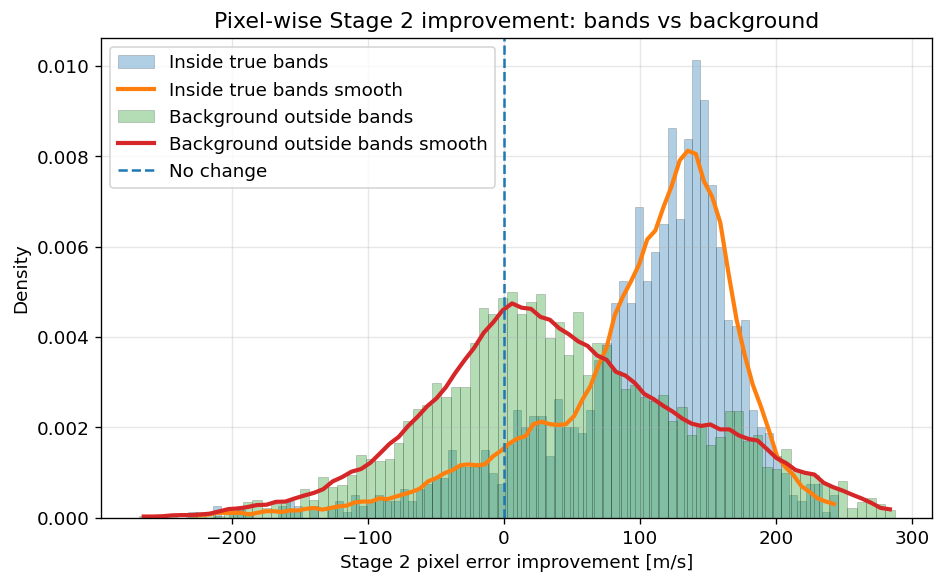

In [34]:
# ============================================================
# Histogram 4: Pixel-wise improvement, bands vs background
# Positive = Stage 2 improved that pixel
# Negative = Stage 2 made it worse
# ============================================================

df_eval = df[
    df["inside_inversion_mask"] == "yes"
].copy()

df_eval["analysis_region"] = np.where(
    df_eval["tectonic_band_number"].notna(),
    "Inside true bands",
    "Background outside bands"
)

plt.figure(figsize=(8, 5))

bins = 80

for region in ["Inside true bands", "Background outside bands"]:

    values = df_eval[
        df_eval["analysis_region"] == region
    ]["stage2_pixel_error_improvement_m_per_s"].dropna().values

    plt.hist(
        values,
        bins=bins,
        density=True,
        alpha=0.35,
        edgecolor="black",
        linewidth=0.3,
        label=region
    )

    cx, cy = smooth_histogram_curve(values, bins=bins, smoothing_window=7)

    plt.plot(
        cx,
        cy,
        linewidth=2.5,
        label=f"{region} smooth"
    )

plt.axvline(0, linewidth=1.5, linestyle="--", label="No change")

plt.title("Pixel-wise Stage 2 improvement: bands vs background")
plt.xlabel("Stage 2 pixel error improvement [m/s]")
plt.ylabel("Density")
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()

save_path = hist_fig_dir / "hist_pixelwise_improvement_bands_vs_background.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
print("Saved:", save_path)

plt.show()

In [37]:
# ============================================================
# Create compact final conclusion CSV for upload
# ============================================================

final_conclusion_rows = []

# ------------------------------------------------------------
# Global summary: Stage 1 vs Stage 2
# ------------------------------------------------------------

for _, row in global_summary.iterrows():

    final_conclusion_rows.append({
        "section": "global_stage1_vs_stage2",
        "experiment_name": row["experiment_name"],
        "experiment_type": row["experiment_type"],
        "num_bands": row["num_bands"],
        "geometry": row["geometry"],
        "metric": row["Metric short name"],
        "stage1_value": row.get(stage1_label, np.nan),
        "stage2_value": row.get(stage2_label, np.nan),
        "improvement_amount": row.get("Improvement amount", np.nan),
        "interpretation": (
            "improved"
            if row.get("Improvement amount", np.nan) > 0
            else "not improved"
        ),
    })


# ------------------------------------------------------------
# Stage 2 resolution-limit summary
# ------------------------------------------------------------

for _, row in resolution_stage2_summary.iterrows():

    for metric in ["MAE", "RMSE", "NRMSE", "Correlation"]:

        if metric in row.index:

            final_conclusion_rows.append({
                "section": "resolution_limit_stage2",
                "experiment_name": row["experiment_name"],
                "experiment_type": "resolution_limit",
                "num_bands": row["num_bands"],
                "geometry": "ideal_horizontal",
                "metric": metric,
                "stage1_value": np.nan,
                "stage2_value": row[metric],
                "improvement_amount": np.nan,
                "interpretation": "Stage 2 metric for resolution-limit comparison",
            })


# ------------------------------------------------------------
# Band recovery summary
# ------------------------------------------------------------

band_summary_metrics = [
    "velocity_update_recovery_percent",
    "MAE_inside_band_m_per_s",
    "RMSE_inside_band_m_per_s",
    "detection_efficiency_0_to_1",
    "false_positive_ratio",
    "wrong_sign_ratio_inside_band",
]

for _, row in band_recovery_summary.iterrows():

    for metric in band_summary_metrics:

        if metric in row.index:

            final_conclusion_rows.append({
                "section": "band_recovery",
                "experiment_name": row["experiment_name"],
                "experiment_type": row["experiment_type"],
                "num_bands": row["num_bands"],
                "geometry": row["geometry"],
                "tectonic_band_number": row["tectonic_band_number"],
                "band_type": row["band_type"],
                "metric": metric,
                "stage": row["FWI stage"],
                "value": row[metric],
                "interpretation": "band-level metric",
            })


# ------------------------------------------------------------
# Background summary
# ------------------------------------------------------------

background_stage_rows = background_all_df[
    background_all_df["FWI stage"].isin([stage1_label, stage2_label, "Stage 2 minus Stage 1"])
].copy()

background_metrics = [
    "MAE_background_m_per_s",
    "RMSE_background_m_per_s",
    "Bias_background_m_per_s",
    "mean_absolute_velocity_update_background_m_per_s",
    "median_absolute_velocity_update_background_m_per_s",
    "max_absolute_velocity_update_background_m_per_s",
    "fraction_background_pixels_abs_update_ge_100_m_per_s",
    "fraction_background_pixels_abs_update_ge_200_m_per_s",
]

for _, row in background_stage_rows.iterrows():

    for metric in background_metrics:

        if metric in row.index:

            final_conclusion_rows.append({
                "section": "background_non_band",
                "experiment_name": row["experiment_name"],
                "experiment_type": row["experiment_type"],
                "num_bands": row["num_bands"],
                "geometry": row["geometry"],
                "metric": metric,
                "stage": row["FWI stage"],
                "value": row[metric],
                "computed_from_map_long": row.get("computed_from_map_long", "unknown"),
                "interpretation": "non-band background metric",
            })


final_conclusion_df = pd.DataFrame(final_conclusion_rows)

final_conclusion_csv = comparison_table_dir / "FINAL_conclusion_metrics_compact.csv"
final_conclusion_df.to_csv(final_conclusion_csv, index=False)

display(final_conclusion_df.head(30))

print("Saved final upload CSV:")
print(final_conclusion_csv)

,section,experiment_name,experiment_type,num_bands,geometry,metric,stage1_value,stage2_value,improvement_amount,interpretation,tectonic_band_number,band_type,stage,value,computed_from_map_long
0,global_stage1_vs_stage2,10 ideal bands,resolution_limit,10,ideal_horizontal,Bias,-18.196907,-0.589087,17.607820,improved,NaN,NaN,NaN,NaN,NaN
1,global_stage1_vs_stage2,10 ideal bands,resolution_limit,10,ideal_horizontal,Correlation,0.364547,0.763063,0.398515,improved,NaN,NaN,NaN,NaN,NaN
2,global_stage1_vs_stage2,10 ideal bands,resolution_limit,10,ideal_horizontal,MAE,151.924713,127.636719,24.287994,improved,NaN,NaN,NaN,NaN,NaN
3,global_stage1_vs_stage2,10 ideal bands,resolution_limit,10,ideal_horizontal,NRMSE,20.549004,14.199347,6.349656,improved,NaN,NaN,NaN,NaN,NaN
4,global_stage1_vs_stage2,10 ideal bands,resolution_limit,10,ideal_horizontal,RMSE,207.947784,143.691772,64.256012,improved,NaN,NaN,NaN,NaN,NaN
5,global_stage1_vs_stage2,3 irregular tectonic bands,realistic_tectonic,3,irregular_tectonic,Bias,-3.239550,0.553171,3.792720,improved,NaN,NaN,NaN,NaN,NaN
6,global_stage1_vs_stage2,3 irregular tectonic bands,realistic_tectonic,3,irregular_tectonic,Correlation,0.723128,0.894706,0.171578,improved,NaN,NaN,NaN,NaN,NaN
7,global_stage1_vs_stage2,3 irregular tectonic bands,realistic_tectonic,3,irregular_tectonic,MAE,147.470108,87.983147,59.486961,improved,NaN,NaN,NaN,NaN,NaN
8,global_stage1_vs_stage2,3 irregular tectonic bands,realistic_tectonic,3,irregular_tectonic,NRMSE,19.018717,12.421044,6.597672,improved,NaN,NaN,NaN,NaN,NaN
9,global_stage1_vs_stage2,3 irregular tectonic bands,realistic_tectonic,3,irregular_tectonic,RMSE,176.423294,115.221321,61.201973,improved,NaN,NaN,NaN,NaN,NaN


Saved final upload CSV:
fwi_comparison_analysis_outputs/tables/FINAL_conclusion_metrics_compact.csv


In [36]:
# ============================================================
# FINAL CONCLUSION SUMMARY CSV
# ============================================================
# Purpose:
#   Create a compact human-readable CSV with the main conclusions
#   from the comparison analysis.
#
# Output:
#   FWI_FINAL_CONCLUSION_SUMMARY.csv
# ============================================================

import numpy as np
import pandas as pd

summary_rows = []


# ============================================================
# Helper functions
# ============================================================

def get_global_value(experiment_name, metric_name, stage_name):
    row = global_summary[
        (global_summary["experiment_name"] == experiment_name)
        & (global_summary["Metric short name"] == metric_name)
    ]

    if row.empty:
        return np.nan

    return float(row[stage_name].iloc[0])


def get_resolution_stage2_value(num_bands, metric_name):
    row = resolution_stage2_summary[
        resolution_stage2_summary["num_bands"] == num_bands
    ]

    if row.empty or metric_name not in row.columns:
        return np.nan

    return float(row[metric_name].iloc[0])


def get_background_value(experiment_name, metric_name, stage_name):
    row = background_all_df[
        (background_all_df["experiment_name"] == experiment_name)
        & (background_all_df["FWI stage"] == stage_name)
    ]

    if row.empty or metric_name not in row.columns:
        return np.nan

    return float(row[metric_name].iloc[0])


def get_band_value(experiment_name, band_number, metric_name, stage_name):
    row = band_recovery_summary[
        (band_recovery_summary["experiment_name"] == experiment_name)
        & (band_recovery_summary["tectonic_band_number"] == band_number)
        & (band_recovery_summary["FWI stage"] == stage_name)
    ]

    if row.empty or metric_name not in row.columns:
        return np.nan

    return float(row[metric_name].iloc[0])


def add_summary_row(
    section,
    conclusion,
    evidence,
    interpretation,
    strength="main"
):
    summary_rows.append({
        "section": section,
        "conclusion": conclusion,
        "evidence": evidence,
        "interpretation": interpretation,
        "strength": strength,
    })


# ============================================================
# 1. Global Stage 1 vs Stage 2 conclusions
# ============================================================

for experiment_name in global_summary["experiment_name"].unique():

    mae1 = get_global_value(experiment_name, "MAE", stage1_label)
    mae2 = get_global_value(experiment_name, "MAE", stage2_label)

    rmse1 = get_global_value(experiment_name, "RMSE", stage1_label)
    rmse2 = get_global_value(experiment_name, "RMSE", stage2_label)

    corr1 = get_global_value(experiment_name, "Correlation", stage1_label)
    corr2 = get_global_value(experiment_name, "Correlation", stage2_label)

    add_summary_row(
        section="Global Stage 1 vs Stage 2",
        conclusion=f"Stage 2 improves the global reconstruction for {experiment_name}.",
        evidence=(
            f"MAE changes from {mae1:.2f} to {mae2:.2f} m/s; "
            f"RMSE changes from {rmse1:.2f} to {rmse2:.2f} m/s; "
            f"correlation changes from {corr1:.3f} to {corr2:.3f}."
        ),
        interpretation=(
            "Stage 2 reduces velocity error and improves spatial agreement "
            "with the true model."
        ),
        strength="main"
    )


# ============================================================
# 2. Resolution-limit conclusion: 6 vs 8 vs 10 bands
# ============================================================

mae6 = get_resolution_stage2_value(6, "MAE")
mae8 = get_resolution_stage2_value(8, "MAE")
mae10 = get_resolution_stage2_value(10, "MAE")

rmse6 = get_resolution_stage2_value(6, "RMSE")
rmse8 = get_resolution_stage2_value(8, "RMSE")
rmse10 = get_resolution_stage2_value(10, "RMSE")

corr6 = get_resolution_stage2_value(6, "Correlation")
corr8 = get_resolution_stage2_value(8, "Correlation")
corr10 = get_resolution_stage2_value(10, "Correlation")

add_summary_row(
    section="Resolution limit",
    conclusion="The ideal-band benchmark shows a practical resolution limit between 6 and 10 bands.",
    evidence=(
        f"Stage 2 MAE increases from {mae6:.2f} m/s for 6 bands, "
        f"to {mae8:.2f} m/s for 8 bands, and {mae10:.2f} m/s for 10 bands. "
        f"Stage 2 RMSE increases from {rmse6:.2f} to {rmse8:.2f} and {rmse10:.2f} m/s. "
        f"Correlation changes from {corr6:.3f} to {corr8:.3f} and {corr10:.3f}."
    ),
    interpretation=(
        "The 6-band case is the most reliable, the 8-band case is borderline, "
        "and the 10-band case behaves as a stress test with stronger error and artifacts."
    ),
    strength="main"
)


# ============================================================
# 3. Irregular tectonic global conclusion
# ============================================================

irregular_name = "3 irregular tectonic bands"

mae1 = get_global_value(irregular_name, "MAE", stage1_label)
mae2 = get_global_value(irregular_name, "MAE", stage2_label)

rmse1 = get_global_value(irregular_name, "RMSE", stage1_label)
rmse2 = get_global_value(irregular_name, "RMSE", stage2_label)

corr1 = get_global_value(irregular_name, "Correlation", stage1_label)
corr2 = get_global_value(irregular_name, "Correlation", stage2_label)

add_summary_row(
    section="Realistic irregular tectonic model",
    conclusion="Stage 2 strongly improves the realistic irregular tectonic reconstruction.",
    evidence=(
        f"For the 3-band irregular case, MAE decreases from {mae1:.2f} to {mae2:.2f} m/s, "
        f"RMSE decreases from {rmse1:.2f} to {rmse2:.2f} m/s, "
        f"and correlation increases from {corr1:.3f} to {corr2:.3f}."
    ),
    interpretation=(
        "The high-frequency continuation improves both average velocity accuracy "
        "and spatial similarity for the realistic tectonic geometry."
    ),
    strength="main"
)


# ============================================================
# 4. Irregular band-by-band recovery conclusions
# ============================================================

for band_number in [1, 2, 3]:

    recovery1 = get_band_value(
        irregular_name,
        band_number,
        "velocity_update_recovery_percent",
        stage1_label
    )

    recovery2 = get_band_value(
        irregular_name,
        band_number,
        "velocity_update_recovery_percent",
        stage2_label
    )

    mae_band1 = get_band_value(
        irregular_name,
        band_number,
        "MAE_inside_band_m_per_s",
        stage1_label
    )

    mae_band2 = get_band_value(
        irregular_name,
        band_number,
        "MAE_inside_band_m_per_s",
        stage2_label
    )

    add_summary_row(
        section="Irregular band recovery",
        conclusion=f"Stage 2 improves velocity recovery for irregular Band {band_number}.",
        evidence=(
            f"Band {band_number} recovery changes from {recovery1:.2f}% to {recovery2:.2f}%; "
            f"MAE inside the band changes from {mae_band1:.2f} to {mae_band2:.2f} m/s."
        ),
        interpretation=(
            "The band-mask evaluation confirms improvement inside the true irregular tectonic region."
        ),
        strength="main"
    )


# ============================================================
# 5. Irregular localization and artifact conclusions
# ============================================================

det1 = []
det2 = []
fp1 = []
fp2 = []
wrong1 = []
wrong2 = []

for band_number in [1, 2, 3]:

    det1.append(get_band_value(irregular_name, band_number, "detection_efficiency_0_to_1", stage1_label))
    det2.append(get_band_value(irregular_name, band_number, "detection_efficiency_0_to_1", stage2_label))

    fp1.append(get_band_value(irregular_name, band_number, "false_positive_ratio", stage1_label))
    fp2.append(get_band_value(irregular_name, band_number, "false_positive_ratio", stage2_label))

    wrong1.append(get_band_value(irregular_name, band_number, "wrong_sign_ratio_inside_band", stage1_label))
    wrong2.append(get_band_value(irregular_name, band_number, "wrong_sign_ratio_inside_band", stage2_label))

add_summary_row(
    section="Irregular mask-based localization",
    conclusion="Stage 2 improves mask-based localization for the irregular tectonic bands.",
    evidence=(
        f"Mean detection efficiency increases from {np.nanmean(det1):.3f} to {np.nanmean(det2):.3f}; "
        f"mean false-positive ratio decreases from {np.nanmean(fp1):.3f} to {np.nanmean(fp2):.3f}; "
        f"mean wrong-sign ratio changes from {np.nanmean(wrong1):.3f} to {np.nanmean(wrong2):.3f}."
    ),
    interpretation=(
        "Because localization is evaluated using the known true irregular masks, "
        "this objectively measures whether correct-sign reconstruction energy is concentrated "
        "inside the true tectonic bands."
    ),
    strength="main"
)


# ============================================================
# 6. Background / non-band conclusions for irregular case
# ============================================================

bg_mae1 = get_background_value(irregular_name, "MAE_background_m_per_s", stage1_label)
bg_mae2 = get_background_value(irregular_name, "MAE_background_m_per_s", stage2_label)

bg_rmse1 = get_background_value(irregular_name, "RMSE_background_m_per_s", stage1_label)
bg_rmse2 = get_background_value(irregular_name, "RMSE_background_m_per_s", stage2_label)

bg_mean_update1 = get_background_value(
    irregular_name,
    "mean_absolute_velocity_update_background_m_per_s",
    stage1_label
)

bg_mean_update2 = get_background_value(
    irregular_name,
    "mean_absolute_velocity_update_background_m_per_s",
    stage2_label
)

bg_max_update1 = get_background_value(
    irregular_name,
    "max_absolute_velocity_update_background_m_per_s",
    stage1_label
)

bg_max_update2 = get_background_value(
    irregular_name,
    "max_absolute_velocity_update_background_m_per_s",
    stage2_label
)

bg_100_1 = get_background_value(
    irregular_name,
    "fraction_background_pixels_abs_update_ge_100_m_per_s",
    stage1_label
)

bg_100_2 = get_background_value(
    irregular_name,
    "fraction_background_pixels_abs_update_ge_100_m_per_s",
    stage2_label
)

bg_200_1 = get_background_value(
    irregular_name,
    "fraction_background_pixels_abs_update_ge_200_m_per_s",
    stage1_label
)

bg_200_2 = get_background_value(
    irregular_name,
    "fraction_background_pixels_abs_update_ge_200_m_per_s",
    stage2_label
)

add_summary_row(
    section="Irregular non-band background",
    conclusion="Stage 2 improves the non-band silicon background on average, but residual artifacts remain.",
    evidence=(
        f"Background MAE decreases from {bg_mae1:.2f} to {bg_mae2:.2f} m/s; "
        f"background RMSE decreases from {bg_rmse1:.2f} to {bg_rmse2:.2f} m/s; "
        f"mean absolute background update decreases from {bg_mean_update1:.2f} to {bg_mean_update2:.2f} m/s. "
        f"Pixels with |dv| >= 100 m/s decrease from {100*bg_100_1:.2f}% to {100*bg_100_2:.2f}%, "
        f"and pixels with |dv| >= 200 m/s decrease from {100*bg_200_1:.2f}% to {100*bg_200_2:.2f}%."
    ),
    interpretation=(
        "The reconstruction becomes cleaner outside the true bands, but the background is not artifact-free."
    ),
    strength="main"
)

add_summary_row(
    section="Irregular non-band background",
    conclusion="Stage 2 can still leave localized high-amplitude artifacts.",
    evidence=(
        f"The maximum absolute background update changes from {bg_max_update1:.2f} "
        f"to {bg_max_update2:.2f} m/s."
    ),
    interpretation=(
        "Although the average background improves, localized artifacts can remain or increase."
    ),
    strength="limitation"
)


# ============================================================
# 7. Background behavior in the 10-band stress test
# ============================================================

bg10_mae1 = get_background_value("10 ideal bands", "MAE_background_m_per_s", stage1_label)
bg10_mae2 = get_background_value("10 ideal bands", "MAE_background_m_per_s", stage2_label)

bg10_200_1 = get_background_value(
    "10 ideal bands",
    "fraction_background_pixels_abs_update_ge_200_m_per_s",
    stage1_label
)

bg10_200_2 = get_background_value(
    "10 ideal bands",
    "fraction_background_pixels_abs_update_ge_200_m_per_s",
    stage2_label
)

add_summary_row(
    section="10-band stress-test background",
    conclusion="The 10-band benchmark shows the strongest artifact limitation.",
    evidence=(
        f"Background MAE changes from {bg10_mae1:.2f} to {bg10_mae2:.2f} m/s, "
        f"and the fraction of background pixels with |dv| >= 200 m/s changes "
        f"from {100*bg10_200_1:.2f}% to {100*bg10_200_2:.2f}%."
    ),
    interpretation=(
        "The dense 10-band case improves in some global metrics, but the background becomes more artifact-prone. "
        "This supports treating it as a stress-test regime."
    ),
    strength="limitation"
)


# ============================================================
# 8. Final synthesis conclusion
# ============================================================

add_summary_row(
    section="Final synthesis",
    conclusion=(
        "The two-stage 20 MHz to 85 MHz FWI workflow is reliable for detecting band presence, "
        "velocity sign, approximate location, and relative velocity strength, but not for exact "
        "artifact-free or boundary-sharp reconstruction."
    ),
    evidence=(
        "Across all experiments, Stage 2 improves global error metrics. The 3-band irregular case improves "
        "inside true masks and in the non-band background. The 6/8/10 benchmarks show increasing difficulty "
        "as band density increases, with the 10-band case behaving as a stress test."
    ),
    interpretation=(
        "The strongest supported claim is successful detection and approximate quantitative recovery, "
        "not exact thickness or perfectly clean imaging."
    ),
    strength="main"
)


# ============================================================
# Save final summary CSV
# ============================================================

final_summary_df = pd.DataFrame(summary_rows)

final_summary_csv = comparison_table_dir / "FWI_FINAL_CONCLUSION_SUMMARY.csv"
final_summary_df.to_csv(final_summary_csv, index=False)

display(final_summary_df)

print("Saved final conclusion summary CSV:")
print(final_summary_csv)

,section,conclusion,evidence,interpretation,strength
0,Global Stage 1 vs Stage 2,Stage 2 improves the global reconstruction for...,MAE changes from 151.92 to 127.64 m/s; RMSE ch...,Stage 2 reduces velocity error and improves sp...,main
1,Global Stage 1 vs Stage 2,Stage 2 improves the global reconstruction for...,MAE changes from 147.47 to 87.98 m/s; RMSE cha...,Stage 2 reduces velocity error and improves sp...,main
2,Global Stage 1 vs Stage 2,Stage 2 improves the global reconstruction for...,MAE changes from 88.15 to 77.77 m/s; RMSE chan...,Stage 2 reduces velocity error and improves sp...,main
3,Global Stage 1 vs Stage 2,Stage 2 improves the global reconstruction for...,MAE changes from 101.40 to 93.27 m/s; RMSE cha...,Stage 2 reduces velocity error and improves sp...,main
4,Resolution limit,The ideal-band benchmark shows a practical res...,Stage 2 MAE increases from 77.77 m/s for 6 ban...,"The 6-band case is the most reliable, the 8-ba...",main
5,Realistic irregular tectonic model,Stage 2 strongly improves the realistic irregu...,"For the 3-band irregular case, MAE decreases f...",The high-frequency continuation improves both ...,main
6,Irregular band recovery,Stage 2 improves velocity recovery for irregul...,Band 1 recovery changes from 63.92% to 92.42%;...,The band-mask evaluation confirms improvement ...,main
7,Irregular band recovery,Stage 2 improves velocity recovery for irregul...,Band 2 recovery changes from 45.07% to 78.34%;...,The band-mask evaluation confirms improvement ...,main
8,Irregular band recovery,Stage 2 improves velocity recovery for irregul...,Band 3 recovery changes from 55.27% to 72.59%;...,The band-mask evaluation confirms improvement ...,main
9,Irregular mask-based localization,Stage 2 improves mask-based localization for t...,Mean detection efficiency increases from 0.765...,Because localization is evaluated using the kn...,main


Saved final conclusion summary CSV:
fwi_comparison_analysis_outputs/tables/FWI_FINAL_CONCLUSION_SUMMARY.csv
